# Imports

In [146]:
import math
import openpyxl
from itertools import combinations
#import osmnx as ox
import networkx as nx
import numpy as np
from shapely.geometry import Point, LineString, Polygon, box
from itertools import combinations
import pickle
import os
from datetime import datetime
import networkx as nx
import pandas as pd
import csv
import matplotlib.pyplot as plt
from pyproj import Proj, transform

https://ec.europa.eu/regional_policy/sources/work/2023-rail-vs-air_en.pdf

# NOTES 

- RAIL
    - Dataframe of rail connections between 76 citys
    - The travel time was scraped from google and DB data
    - The time to get to the nearest stations from the city centers
-----
- additionly notes - city names are fucked up, they are written differently in different data, so when we are going to be choosing the size of the city, we have to check if all the data is there, so far all cities above 500 000 have coordinates, but not all are assigned with the airport, probably will have to add some manually, also not all airport assigned have coordinates
- flight route database is 7 y old - kind of old

- data
- https://ec.europa.eu/eurostat/databrowser/view/urb_cpop1/default/table?lang=en&category=urb.urb_cgc
- https://public.opendatasoft.com/explore/dataset/geonames-all-cities-with-a-population-1000/export/?disjunctive.cou_name_en&sort=name&refine.timezone=Europe
- https://www.partow.net/miscellaneous/airportdatabase/
- the rest - from kaggle


## Narrowing down the scope
- transit points to the airport and station from a city center
    - for reducing workload, we set an estimate for the airport travel time of 1 hour to the station (assuming it to be near to the city center) 0.5 hour (2nd not agreed yet, suggestion Hedda),
    - Addition: research found that travellers spent an average of 157 minutes at airports and 32 minutes at railway stations (https://opentransportationjournal.com/VOLUME/13/PAGE/48/FULLTEXT/) adding that, too?
- considering only cities with population > 500.000
- considering only flights with direct connections

## Open Q's Hedda
- Can we add the countries to the cities df? In the source, they have the Codes indicating the countries
- What about cities that do not have an airport? Do we already have a solution for that?


## Air data gathering and preprocessing

### Cities and Population Sizes
- **Dataset**: Excel file containing city names and population sizes.
- link - https://ec.europa.eu/eurostat/databrowser/view/urb_cpop1/default/table?lang=en&category=urb.urb_cgc
- The dataset was cleaned by renaming columns, replacing non-numeric values, and filtering out invalid rows. Specific markers or special values were removed, and unnecessary data such as countries and regions was excluded. Columns were converted to numeric format, and rows with missing or invalid data were dropped. For each city, the latest population data was identified, creating a new DataFrame with city names and population sizes, sorted by population. Additional steps included standardizing city names, removing non-city entries, and replacing unofficial city names with official counterparts.

In [116]:
# CITIES AND POPULATION SIZES 

file_path = 'data/cities-population-sizes/cities-popsize.xlsx'  
df = pd.read_excel(file_path, header=8)

# Rename the first column to "CITIES (Labels)"
df.rename(columns={df.columns[0]: "CITIES (Labels)"}, inplace=True)

# Replace any non-numeric population values (like ':', 'b', 'd', etc.) with NaN
df.replace({':': pd.NA, 'b': pd.NA, 'd': pd.NA, 'e': pd.NA, 'p': pd.NA}, inplace=True)

# Drop rows where the 'CITIES (Labels)' column is NaN or contains invalid values
df = df[~df['CITIES (Labels)'].isin(['Available flags:', 'Special value', ':', 'b', 'd', 'e', 'p'])]

# Find the index where 'Türkiye' is in the "CITIES (Labels)" column
turkiye_index = df[df['CITIES (Labels)'] == 'Türkiye'].index[0]

# Remove all rows up to and including the row with "Türkiye"
df = df.iloc[turkiye_index+1:]

# Ensure the columns with years are in numeric format, and drop any invalid values
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# Drop rows where the 'CITIES (Labels)' column is NaN
df = df[df['CITIES (Labels)'].notna()]

# Now proceed with finding the latest population for each city
latest_years = []
latest_populations = []

# Iterate over each row (city) to find the latest non-NaN population value and year
for index, row in df.iterrows():
    # Find the last non-NaN population value and its corresponding year
    latest_year = row.dropna().index[-1]  # Get the last non-NaN column (year)
    latest_population = row[latest_year]  # Get the population value for that year
    # Append the results to the lists
    latest_years.append(latest_year)
    latest_populations.append(latest_population)

# Create a new DataFrame with the city names, latest year, and latest population size
latest_df = pd.DataFrame({
    'City': df['CITIES (Labels)'],
    'Population': latest_populations
})
latest_df_sorted = latest_df.sort_values(by='Population', ascending=False)
latest_df_sorted = latest_df_sorted[latest_df_sorted['Population'] > 500000].sort_values(by='Population', ascending=False)

# Standardize cities in the latest_df_sorted
latest_df_sorted['City'] = latest_df_sorted['City'].str.strip().str.lower()

# removing data which isn't actually cities
entries_to_remove = [
    'kirklees', 'north lanarkshire (airdrie/bellshill/coatbridge/motherwell)',
    'cheshire west and chester', 'sandwell', 'wirral', 'brighton and hove',
    'medway', 'sefton', 'greater valletta', 'trafford', 'tameside', 'north tyneside'
]
latest_df_sorted = latest_df_sorted[~latest_df_sorted['City'].isin(entries_to_remove)]
latest_df_sorted.reset_index(drop=True, inplace=True)

# City replacements for cities with names that aren't official
city_replacements = {
    'bruxelles/brussel': 'brussels',
    'helsinki/helsingfors': 'helsinki',
    'lódz': 'lodz', 
    "'s-gravenhage": 'hague', 
    'alicante/alacant':'alicante',
    'pamplona/iruña':'pamplona',
    'espoo/esbo':'espoo',
    'vitoria/gasteiz':'vitoria',
    'tampere/tammerfors':'tampere', 
    'vantaa/vanda':'vantaa', 
    'oulu/uleåborg':'oulu', 
    'elche/elx':'elche',
    'turku/åbo':'turku', 
    'wien':'vienna', 
    'roma':'rome',
    'bucuresti':'bucarest', 
    'napoli':'naples',
    'praha':'prague', 
    'münchen':'munich'
}
latest_df_sorted['City'] = latest_df_sorted['City'].replace(to_replace=city_replacements)

print(latest_df_sorted)

          City  Population
0        paris  10306512.0
1     istanbul   9897599.0
2       london   8866541.0
3       madrid   5115272.0
4    barcelona   3767382.0
..         ...         ...
141     galati    304050.0
142     kaunas    302875.0
143    craiova    301269.0
144   augsburg    301033.0
145    denizli    300081.0

[146 rows x 2 columns]


### Cities and Their Coordinates
- **Dataset**: CSV file with geographical coordinates for cities with populations over 1,000.
- link - https://public.opendatasoft.com/explore/dataset/geonames-all-cities-with-a-population-1000/export/?disjunctive.cou_name_en&sort=name&refine.timezone=Europe 
- The dataset was merged with the city population data to incorporate geographical coordinates. Missing coordinates were resolved using alternative and ASCII names, and coordinates were split into latitude and longitude. Faulty entries were filtered out, and specific updates, such as correcting certain coordinates, were applied. This resulted in a comprehensive DataFrame with accurate city names, population sizes, and geographical coordinates.

In [117]:
# CITIES AND THEIR COORDINATES

city_data = pd.read_csv("data/coordinates/geonames-all-cities-with-a-population-1000.csv", delimiter=';')

# Clean columns in city_data
city_data.rename(columns={'Name': 'City'}, inplace=True)
city_data['City'] = city_data['City'].str.strip().str.lower()
city_data['ASCII Name'] = city_data['ASCII Name'].str.strip().str.lower()
city_data['Alternate Names'] = city_data['Alternate Names'].str.strip().str.lower()

# Merge latest_df_sorted with city_data for coordinates, ASCII Name, and Alternate Names
merged_df = pd.merge(
    latest_df_sorted,
    city_data[['City', 'Coordinates', 'ASCII Name', 'Alternate Names']],
    on='City',
    how='left'
)

# Function to find coordinates based on Alternate Names
def find_coordinates(city, city_data):
    # Check if the city is in 'ASCII Name'
    row = city_data[
        (city_data['ASCII Name'] == city)
    ]
    
    # If not found, check if the city is in 'Alternate Names'
    if row.empty:
        row = city_data[
            city_data['Alternate Names'].str.contains(fr'\b{city}\b', na=False)
        ]
    
    if not row.empty:
        return row.iloc[0]['Coordinates'], row.iloc[0]['ASCII Name'], row.iloc[0]['Alternate Names']
    return None, None, None

# Resolve missing coordinates and update the DataFrame
missing_coords = merged_df[merged_df['Coordinates'].isna()]
for index, row in missing_coords.iterrows():
    city = row['City']
    coordinates, ascii_name, alternate_names = find_coordinates(city, city_data)
    if coordinates:
        merged_df.loc[index, 'Coordinates'] = coordinates
        merged_df.loc[index, 'ASCII Name'] = ascii_name
        merged_df.loc[index, 'Alternate Names'] = alternate_names

# Split 'Coordinates' into 'CityLatitude' and 'CityLongitude'
if 'Coordinates' in merged_df.columns:
    merged_df[['CityLatitude', 'CityLongitude']] = merged_df['Coordinates'].str.split(',', expand=True)
    merged_df['CityLatitude'] = pd.to_numeric(merged_df['CityLatitude'], errors='coerce')
    merged_df['CityLongitude'] = pd.to_numeric(merged_df['CityLongitude'], errors='coerce')
    merged_df.drop(columns=['Coordinates'], inplace=True)

merged_df = merged_df[~((merged_df['CityLatitude'] == 51.24197) & (merged_df['CityLongitude'] == 4.82313))]
merged_df = merged_df[~((merged_df['CityLatitude'] == 42.16737) & (merged_df['CityLongitude'] == -6.89934))]
merged_df = merged_df[~((merged_df['CityLatitude'] == 40.84395) & (merged_df['CityLongitude'] == 14.25724))]
merged_df = merged_df[~((merged_df['CityLatitude'] == 51.46791) & (merged_df['CityLongitude'] == 4.46901))]
merged_df = merged_df[~((merged_df['CityLatitude'] == 52.72258) & (merged_df['CityLongitude'] == 7.93710))]
merged_df = merged_df[~((merged_df['CityLatitude'] == 50.81584) & (merged_df['CityLongitude'] == 4.55533))]

# Update the coordinates for "hague"
the_hague_coordinates = {'CityLatitude': 52.0705, 'CityLongitude': 4.3007}
merged_df.loc[merged_df['City'] == 'hague', ['CityLatitude', 'CityLongitude']] = the_hague_coordinates['CityLatitude'], the_hague_coordinates['CityLongitude']

print(merged_df[['City', 'Population', 'CityLatitude', 'CityLongitude']])
#print(merged_df[(merged_df['City'] == 'hague')])

# Check for rows with missing coordinates
missing_coordinates = merged_df[merged_df['CityLatitude'].isna() | merged_df['CityLongitude'].isna()]
if not missing_coordinates.empty:
    print("Rows with missing CityLatitude or CityLongitude:")
    print(missing_coordinates)
else:
    print("No missing coordinates found.")

          City  Population  CityLatitude  CityLongitude
0        paris  10306512.0      48.85341        2.34880
1     istanbul   9897599.0      41.01384       28.94966
2       london   8866541.0      51.50853       -0.12574
3       madrid   5115272.0      40.41650       -3.70256
4    barcelona   3767382.0      41.38879        2.15899
..         ...         ...           ...            ...
152     galati    304050.0      45.43687       28.05028
153     kaunas    302875.0      54.90272       23.90961
154    craiova    301269.0      44.31667       23.80000
155   augsburg    301033.0      48.37154       10.89851
156    denizli    300081.0      37.77417       29.08750

[151 rows x 4 columns]
Rows with missing CityLatitude or CityLongitude:
                       City  Population ASCII Name Alternate Names  \
105              las palmas    380863.0        NaN             NaN   
110  santa cruz de tenerife    368482.0        NaN             NaN   

     CityLatitude  CityLongitude  
105      

### Airport Names and Codes
- **Dataset**: CSV file containing airport names and IATA codes.
- link - https://www.kaggle.com/datasets/rusiano/european-airports-iata-codes
- The city dataset was merged with airport data to assign airport names to cities, matching airport names to city names and alternative city names. Airport names were split to ensure each row represented a single airport. Missing airport information was updated manually where necessary, resulting in a detailed DataFrame linking cities with their corresponding airport names and codes.

In [8]:
# AIRPORT NAMES AND CODES

airport_data = pd.read_csv(
    "data/european-airports-iata-codes/european_iatas_df.xls",
    header=None, usecols=[0, 1, 2]
)
airport_data.columns = ['City', 'Airport_Name', 'Airport_Code']
airport_data['City'] = airport_data['City'].str.strip().str.lower()
airport_data['Airport_Name'] = airport_data['Airport_Name'].str.strip()

# Ensure merged_df's columns are in a comparable format
merged_df['City'] = merged_df['City'].str.strip().str.lower()
merged_df['ASCII Name'] = merged_df['ASCII Name'].str.strip().str.lower()
merged_df['Alternate Names'] = merged_df['Alternate Names'].str.strip().str.lower()

# Add an empty column for the airport name
merged_df['Airport_Name'] = ''

# Match and add airport names
for _, row in airport_data.iterrows():
    airport_city = row['City']
    airport_name = row['Airport_Name']
    
    # Check if the airport city matches any city-related column
    merged_df.loc[
        (merged_df['City'] == airport_city) |
        (merged_df['ASCII Name'] == airport_city) |
        (merged_df['Alternate Names'].str.contains(fr'\b{airport_city}\b', na=False, regex=True)),
        'Airport_Name'
    ] += f"{airport_name}; "

# Clean up any trailing "; " from the Airport_Name column
merged_df['Airport_Name'] = merged_df['Airport_Name'].str.rstrip("; ")

# Update row for Bordeaux cause its also called porto in alternate names
merged_df.loc[merged_df['City'] == 'bordeaux', 'Airport_Name'] = \
    merged_df.loc[merged_df['City'] == 'bordeaux', 'Airport_Name'].str.replace('Francisco Sá Carneiro Airport', '', regex=False)
merged_df['Airport_Name'] = merged_df['Airport_Name'].str.replace(r';\s*;', ';', regex=True).str.strip('; ')

# change to airport per line
airport_names_split = merged_df['Airport_Name'].str.split(';', expand=True)
# Reshape the DataFrame to repeat other columns for each airport
# Use `melt` to convert wide format to long format
merged_df_repeated = merged_df.drop(columns='Airport_Name').join(airport_names_split)
#print(merged_df_repeated[merged_df_repeated['City'] == 'bordeaux'])
# Step 3: Melt the DataFrame, keeping the 'City', 'Population', etc. columns intact
expanded_df = merged_df_repeated.melt(id_vars=merged_df.columns[:-1], value_name='Airport_Name')
# Step 4: Drop rows where 'Airport_Name' is NaN (empty cells after melting)
expanded_df = expanded_df.dropna(subset=['Airport_Name'])
expanded_df.reset_index(drop=True, inplace=True)
expanded_df = expanded_df.sort_values(by='Population', ascending=False)

expanded_df['Airport_Name'] = expanded_df['Airport_Name'].str.strip()
airport_data['Airport_Name'] = airport_data['Airport_Name'].str.strip()
# Merge on Airport_Name only
expanded_df = expanded_df.merge(
    airport_data[['Airport_Name', 'Airport_Code']],
    on='Airport_Name', 
    how='left'
)

airport_updates = {
    'hague': {'Airport_Name': 'Rotterdam The Hague Airport', 'Airport_Code': 'RTM', 'City': 'hague'},
    'bilbao': {'Airport_Name': 'Bilbao Airport', 'Airport_Code': 'BIO', 'City': 'bilbao'},
    'diyarbakir': {'Airport_Name': 'Diyarbakır Airport', 'Airport_Code': 'DIY', 'City': 'diyarbakir'},
    'essen': {'Airport_Name': 'Düsseldorf International Airport', 'Airport_Code': 'DUS', 'City': 'essen'},
    'sheffield': {'Airport_Name': 'Doncaster Sheffield Airport', 'Airport_Code': 'DSA', 'City': 'sheffield'},
    'dresden': {'Airport_Name': 'Dresden Airport', 'Airport_Code': 'DRS', 'City': 'dresden'},
    'bradford': {'Airport_Name': 'Leeds Bradford Airport', 'Airport_Code': 'LBA', 'City': 'bradford'},
    'duisburg': {'Airport_Name': 'Düsseldorf International Airport', 'Airport_Code': 'DUS', 'City': 'duisburg'}
}

# Update the DataFrame with new airport names, airport codes, and corrected city names
for city, updates in airport_updates.items():
    expanded_df.loc[expanded_df['City'] == city, ['City', 'Airport_Name', 'Airport_Code']] = \
        updates['City'], updates['Airport_Name'], updates['Airport_Code']

# Filter the rows without missing Airport_Name
expanded_df_no_missing_airport = expanded_df[expanded_df['Airport_Name'] != '']

# Print the desired columns of the cleaned dataframe
print(expanded_df_no_missing_airport[['City', 'Population', 'Airport_Name', 'Airport_Code']])

# Rows with no assigned airport code
print("")
no_airport_rows = expanded_df[expanded_df['Airport_Name'] == '']
if no_airport_rows.empty:
    print("No rows with missing Airport Name")
else:
    print("Rows with missing Airport Name:")
    print(no_airport_rows[['City', 'Population', 'Airport_Name', 'Airport_Code']])

             City  Population                               Airport_Name  \
0           paris  10306512.0                  Charles de Gaulle Airport   
1           paris  10306512.0                               Orly Airport   
2        istanbul   9897599.0        Sabiha Gökçen International Airport   
3        istanbul   9897599.0              Atatürk International Airport   
4          london   8866541.0                        London City Airport   
..            ...         ...                                        ...   
162          bari    316736.0                             Palese Airport   
164  thessaloniki    315196.0         Thessaloniki International Airport   
166     constanta    313021.0  Mihail Kogălniceanu International Airport   
167     doncaster    309741.0     Robin Hood Airport Doncaster Sheffield   
170        kaunas    302875.0                             Kaunas Airport   

    Airport_Code  
0            CDG  
1            ORY  
2            SAW  
3          

### Airport Coordinates
- **Dataset**: Text file with global airport coordinates.
- https://www.partow.net/miscellaneous/airportdatabase/ 
- Latitude and longitude values were converted to decimal format, and relevant columns were extracted and cleaned. The data was merged with the city-airport dataset to include airport coordinates. Specific updates were made to ensure accuracy, and faulty entries were filtered out. The final DataFrame linked cities with their population sizes, airport names, codes, and accurate geographical coordinates.

In [9]:
# AIRPORT COORDINATES

# Define a function to convert to decimal coordinates
def to_decimal(degrees, minutes, seconds, direction):
    decimal = float(degrees) + float(minutes) / 60 + float(seconds) / 3600
    if direction in ['S', 'W']:  # Negative for south and west
        decimal = -decimal
    return decimal

# Read the data from a text file
data = pd.read_csv("data/airports-coordinates/GlobalAirportDatabase.txt", sep=":", header=None, encoding='utf-8')

# Extract relevant columns: IATA Code, City, Latitude, Longitude
data_extracted = data[[1, 5, 6, 7, 8, 9, 10, 11, 12]].copy()  # Add .copy() to avoid the warning

# Convert Latitude and Longitude to decimal format using .loc to avoid SettingWithCopyWarning
data_extracted.loc[:, 'Latitude_Decimal'] = data_extracted.apply(
    lambda row: to_decimal(row[5], row[6], row[7], row[8]), axis=1
)
data_extracted.loc[:, 'Longitude_Decimal'] = data_extracted.apply(
    lambda row: to_decimal(row[9], row[10], row[11], row[12]), axis=1
)

# Select only the columns for IATA, City, Latitude, and Longitude
final_data = data_extracted[[1, 'Latitude_Decimal', 'Longitude_Decimal']]

# Rename columns to include Airport Code instead of IATA
final_data.columns = ['Airport_Code', 'AirportLatitude', 'AirportLongitude']
final_data = final_data.dropna(subset=['Airport_Code'])
final_data = final_data[(final_data['AirportLatitude'] != 0) & (final_data['AirportLongitude'] != 0)]

# Print the result
print(final_data)

     Airport_Code  AirportLatitude  AirportLongitude
0             GKA        -6.081667        145.391667
2             MAG        -5.206944        145.788611
3             HGU        -5.826111        144.296111
4             LAE        -6.569722        146.726111
5             POM        -9.443333        147.220000
...           ...              ...               ...
9275          KHG        39.543333         76.021667
9276          HTN        37.037778         79.865833
9278          URC        43.906944         87.474167
9286          HRB        45.623333        126.250278
9296          DLC        38.965556        121.538333

[2948 rows x 3 columns]


In [11]:
df = expanded_df_no_missing_airport.merge(final_data, how='left', on='Airport_Code')

df = df[~((df['City'] == 'antalya') & 
          (df['Population'] == 689665.0) & 
          (df['Airport_Name'] == 'Costa Smeralda Airport'))]

# Dictionary with airport coordinates
airport_coords = {
    'SAW': {'Latitude': 40.8986, 'Longitude': 29.3092},
    'BER': {'Latitude': 52.3667, 'Longitude': 13.5033},
    'ATH': {'Latitude': 37.9364, 'Longitude': 23.9445},
    'WMI': {'Latitude': 52.4511, 'Longitude': 20.6518},
    'YEI': {'Latitude': 40.2552, 'Longitude': 29.5626},
    'RYG': {'Latitude': 59.3789, 'Longitude': 10.7856},
    'LCJ': {'Latitude': 51.7219, 'Longitude': 19.3981},
    'RIX': {'Latitude': 56.9236, 'Longitude': 23.9711},
    'VNO': {'Latitude': 54.6341, 'Longitude': 25.2858},
    'DSA': {'Latitude': 53.4805, 'Longitude': -1.0107}
}

# Update the DataFrame with airport coordinates
for code, coords in airport_coords.items():
    df.loc[df['Airport_Code'] == code, 'AirportLatitude'] = coords['Latitude']
    df.loc[df['Airport_Code'] == code, 'AirportLongitude'] = coords['Longitude']

df['AirportCityDistance'] = df.apply(lambda row: haversine(
    row['CityLatitude'], row['CityLongitude'], 
    row['AirportLatitude'], row['AirportLongitude']
), axis=1)

df = df.sort_values(by='AirportCityDistance', ascending=False)
non_nan_airport_coordinates_df = df.dropna(subset=['AirportLatitude'])
# Print the result
print(non_nan_airport_coordinates_df[['City', 'Population', 'Airport_Name', 'Airport_Code', 'CityLatitude', 'CityLongitude', 'AirportLatitude', 'AirportLongitude', 'AirportCityDistance']])

non_nan_airport_coordinates_df.to_csv('data/cities/citiesandairports.csv', index = False)

# Filter rows where 'AirportLatitude' is NaN
print("")
df_with_nan_latitude = df[df['AirportLatitude'].isna()]
if df_with_nan_latitude.empty:
    print("No rows with missing Airport Coordinates")
else:
    print("Rows with missing Airport Coordinates:")
    print(df_with_nan_latitude[['City', 'Population', 'Airport_Name', 'Airport_Code', 'CityLatitude', 'CityLongitude', 'AirportLatitude', 'AirportLongitude']]) 

                  City  Population                      Airport_Name  \
134              varna    332686.0                     Varna Airport   
135              varna    332686.0                     Varna Airport   
60   frankfurt am main    773068.0            Frankfurt-Hahn Airport   
31           stockholm   1613975.0         Stockholm-Skavsta Airport   
32           stockholm   1613975.0        Stockholm-Västerås Airport   
..                 ...         ...                               ...   
130            belfast    341049.0  George Best Belfast City Airport   
44               adana   1197332.0                 Şakirpaşa Airport   
92              bremen    569396.0                    Bremen Airport   
85          diyarbakir    609465.0                Diyarbakır Airport   
123               iasi    378954.0        Iași International Airport   

    Airport_Code  CityLatitude  CityLongitude  AirportLatitude  \
134          VAR      46.73901       11.63749        43.231944   
135

### Calculating Distances
- **Dataset**: Combination of city-airport data and airport coordinates.
- Functions were defined for calculating distances using the Haversine formula and estimating travel times. Unique city pairs were generated, and distances and air travel times between these pairs were computed, resulting in a DataFrame showing pairwise air travel times between cities.

In [10]:
# HAVERSINE - ESTIMATING AIR DISTANCE

import math

def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points on the Earth."""
    R = 6371  # Earth radius in km
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c


def air_travel_time(distance, speed=900, airport_time=2.5, airportcitydistance=20, airportcitydrivingspeed=60):
    """Estimate total air travel time in hours, with transit time calculated from airport city distance and driving speed."""
    flight_time = distance / speed
    transit_time = airportcitydistance / airportcitydrivingspeed
    return flight_time + airport_time + transit_time


def rail_travel_time(distance, speed=120, station_time=0.5):
    """Estimate total rail travel time in hours."""
    travel_time = distance / speed
    return travel_time + station_time

In [12]:
# CALCULATING DISTANCES

processed_pairs = set()  # Set to track processed pairs

city_pairs = [
    ((row1['City'], row1['AirportLatitude'], row1['AirportLongitude'], row1['Airport_Code'], row1['AirportCityDistance']),
     (row2['City'], row2['AirportLatitude'], row2['AirportLongitude'], row2['Airport_Code'], row2['AirportCityDistance']))
    for index1, row1 in non_nan_airport_coordinates_df.iterrows()
    for index2, row2 in df.iterrows()
    if index1 < index2 and row1['City'] != row2['City']  # Ensure distinct cities
]

# Now filter out duplicate pairs
unique_city_pairs = []
for (city1, lat1, lon1, cod1, dist1), (city2, lat2, lon2, cod2, dist2) in city_pairs:
    sorted_pair = tuple(sorted([(city1, lat1, lon1, cod1), (city2, lat2, lon2, cod2)]))  # Sort cities to avoid reverse duplicates
    if sorted_pair not in processed_pairs:
        processed_pairs.add(sorted_pair)
        unique_city_pairs.append(((city1, lat1, lon1, cod1, dist1), (city2, lat2, lon2, cod2, dist2)))

# Calculate distances and air travel times
travel_data = []
for (city1, lat1, lon1, cod1, airportcitydistance1), (city2, lat2, lon2, cod2, airportcitydistance2) in unique_city_pairs:
    if not (pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2)):
        distance = haversine(lat1, lon1, lat2, lon2)
        # Assuming both cities have the same driving speed for simplicity
        travel_time = air_travel_time(distance, airportcitydistance=airportcitydistance1, airportcitydrivingspeed=60)
        travel_data.append((city1, lat1, lon1, cod1, city2, lat2, lon2, cod2, distance, travel_time))

# Create a dataframe with the results
travel_df = pd.DataFrame(travel_data, columns=['City1', 'AirportLat1', 'AirportLon1', 'Airport_Code1', 'City2', 'AirportLat2', 'AirportLon2', 'Airport_Code2', 'Distance (km)', 'Air Travel Time (h)'])
travel_df = travel_df.sort_values(by='Air Travel Time (h)', ascending=False)

# Display the dataframe
print("City Pairwise Air Travel Times:")
print(travel_df)


City Pairwise Air Travel Times:
           City1  AirportLat1  AirportLon1 Airport_Code1       City2  \
2          varna    43.231944    27.825000           VAR  nottingham   
6          varna    43.231944    27.825000           VAR   doncaster   
0          varna    43.231944    27.825000           VAR       århus   
5          varna    43.231944    27.825000           VAR        bari   
4          varna    43.231944    27.825000           VAR   timisoara   
...          ...          ...          ...           ...         ...   
9454      bremen    53.047500     8.786667           BRE    hannover   
8966   rotterdam    51.957222     4.441667           RTM   amsterdam   
8073  düsseldorf    51.289444     6.766667           DUS    duisburg   
8067  düsseldorf    51.289444     6.766667           DUS       essen   
8949   rotterdam    51.957222     4.441667           RTM       hague   

      AirportLat2  AirportLon2 Airport_Code2  Distance (km)  \
2       52.831111    -1.328056          

### Filtering Routes That Exist
- **Dataset**: CSV file containing flight route information.
- link - https://www.kaggle.com/datasets/open-flights/flight-route-database
- Direct flight routes were identified by filtering city pairs based on route availability in the dataset. City pairs with and without direct flights were listed, resulting in DataFrames that indicated whether direct routes exist between city pairs.

In [15]:
# FILTERING ROUTES THAT EXIST 

route_db = pd.read_csv('data/flight-route-database/routes.csv.zip', header=None, low_memory=False)  # Load CSV without headers

# Set column names for the route database
route_db.columns = [
    'airline',              # Name of the airline
    'airline ID',           # Airline ID
    'source airport',       # Source airport code
    'source airport ID',    # Source airport ID
    'destination airport',  # Destination airport code
    'destination airport ID',  # Destination airport ID
    'codeshare',            # Codeshare information
    'stops',                # Number of stops
    'equipment'             # Equipment used
]
route_set = set(zip(route_db['source airport'], route_db['destination airport']))
travel_df['Route Exists'] = travel_df.apply(
    lambda row: (row['Airport_Code1'], row['Airport_Code2']) in route_set,
    axis=1
)

routes_exist_df = travel_df.loc[travel_df['Route Exists']]
routes_exist_not_df = travel_df.loc[travel_df['Route Exists'] == False]

print('Direct routes exist:')
print(f'Number of rows: {routes_exist_df.shape[0]}')
print(routes_exist_df[['City1', 'Airport_Code1', 'City2', 'Airport_Code2', 'Air Travel Time (h)']])
print('')
print('')
print('Direct routes do not exist:')
print(f'Number of rows: {routes_exist_not_df.shape[0]}')
print(routes_exist_not_df[['City1', 'Airport_Code1', 'City2', 'Airport_Code2', 'Air Travel Time (h)']])

Direct routes exist:
Number of rows: 1531
          City1 Airport_Code1       City2 Airport_Code2  Air Travel Time (h)
157   stockholm           VST      málaga           AGP             7.227228
88    stockholm           NYO      málaga           AGP             7.218854
198        oslo           TRF     antalya           AYT             7.125708
196        oslo           TRF      málaga           AGP             6.943544
228        oslo           RYG      málaga           AGP             6.549409
...         ...           ...         ...           ...                  ...
3437  amsterdam           AMS    duisburg           DUS             2.885207
3468  amsterdam           AMS  düsseldorf           DUS             2.885207
3225   brussels           BRU   amsterdam           AMS             2.874709
3562     zürich           ZRH   stuttgart           STR             2.842933
5060     naples           NAP        rome           FCO             2.790844

[1531 rows x 5 columns]


Direct 

### Saving air dataset

In [17]:
routes_exist_df.to_csv('data/air-data/df_air.csv', index = False)

## Data Set Collection for Rail Travel Time

Methodology of paper:

1. *Station Selection* based on where time schedule data was available (I think they did it based on this MERITS database, not for free) (https://uic.org/passenger/passenger-services-group/merits#MERITS-FAQ):

- Selected stations in major urban centers
    - our definition of "urban center" for the time being would be cities above 500.000 population size
    - Kaggle dataset with train stations: https://www.kaggle.com/datasets/headsortails/train-stations-in-europe/data
      
- For cities with >10 stations, filtered to major stations based on:
    - Total departures between 6:00-20:00
    - Maximum length of direct trips
    - Station names
 
2. *Rail Travel Time Calculation:*

- Used OpenTripPlanner Analyst (how can we estimate that in an easier way OR use it, too?)
- https://docs.opentripplanner.org/en/latest/
- For me, it looks really complicated to use, but maybe you guys can have a look
    - Calculated best travel time every 15 minutes (4:00-23:45) on weekdays in 2019
        - Key parameters:
        - Max walking distance: 900m
        - Walking speed: 1.33 m/s
        - Maximum transfers: 5
        - Maximum trip time: 10 hours
        - Transit modes: rail, subway, walk
          
- Another idea would be to somehow scrape the travel time data, but I would not know how, and it also seems a bit too much effort. (what we need is GTFS data https://gtfs.org/getting-started/what-is-GTFS/; maybe here: https://www.transit.land/)
        
     
3. *TEN-T Network Analysis*:
- Here the actual TEN-T Map is available, and passenger railways, urban centers and even airports can be selected, but I don't know where to get the acutal data behind https://webgate.ec.europa.eu/tentec-maps/web/public/screen/home
- They talk about an API here (https://transport.ec.europa.eu/transport-themes/infrastructure-and-investment/trans-european-transport-network-ten-t/tentec-information-system-and-ten-t-map-library_en), but I cannot find it anywhere
- The place it should be would be here, but here they only have rather old data for port and airport: https://ec.europa.eu/eurostat/web/gisco/geodata/transport-networks
- I have requested access to the TENtec platfrom, hopefully I get access and the respective data is there

- Mapped connections to TEN-T rail network
    - Snapped city centroids to core network
    - Snapped to comprehensive network
    - Validated routes (network length ≤ 2.5× straight-line distance)
    - Prioritized core routes over comprehensive routes
    - Calculated network speeds and corrected outliers


4. Total Travel Time Calculation:
Sum of:
    - Car time from city center to departure station
    - Station transfer time (15 minutes)
    - Best available rail travel time
    - Car time from arrival station to destination city center
  
A really bad fallback solution would be to take the geodesic distance (straight line) and add the mean speed of the train. or manually input distances / times from researching ...

-> If we do not find a good solution until next week, we can ask in the review meeting.


Other potential sources:
- https://direkt.bahn.guru/?origin=8103000
    - they only use the API from DB: https://gist.github.com/juliuste/f9776a6b7925bc6cc2d52225dd83336e
    - this project also uses direct bahn guru: https://www.chronotrains.com/de/about
      
- https://www.openrailwaymap.org/
    - data on train routes from openstreetmap data: http://osmtrainroutes.bplaced.net/
 
- https://uic-stats.uic.org/select/ Here, a lot of data on rail is available, but I did not find anything for our specific topic



In [ ]:
# kaggle dataset on train stations
df_trainstations = pd.read_csv('data/train-stations-europe/train_stations_europe.csv.zip')

print("\n=== Dataset Info ===")
print(df_trainstations.info())

print("\n=== First few rows ===")
print(df_trainstations.head())

In [41]:
# clean df, 
# match cities to the stations,
# filter df according to the cities >= 500.000

# Open Street Map Data via osmnx

In [2]:
class RailConnectionAnalyzer:
    def __init__(self, cities_df):
        """
        Initialize with DataFrame of European cities.
        
        Parameters:
        cities_df: DataFrame with columns:
            - City: Name of the city
            - CityLatitude: City latitude
            - CityLongitude: City longitude
        """
        self.cities = cities_df.copy() 
        self.G = None
        self.connections = None
        self.cache_dir = 'rail_cache'
        
        if not os.path.exists(self.cache_dir):
            os.makedirs(self.cache_dir)
    
    def _get_cache_filename(self, bbox_buffer):
        """Generate a unique cache filename based on cities and buffer."""
        # Use hash of sorted city names to create unique identifier
        cities_str = '_'.join(sorted(self.cities['City']))
        return os.path.join(self.cache_dir, f"european_rail_{hash(cities_str)}_{bbox_buffer}.pkl")
    
    def get_railway_network(self, bbox_buffer=0.05, use_cache=True):
        """Get railway network, using cached data if available."""
        cache_file = self._get_cache_filename(bbox_buffer)
        
        if use_cache and os.path.exists(cache_file):
            print("Loading network from cache...")
            try:
                with open(cache_file, 'rb') as f:
                    self.G = pickle.load(f)
                print("Network loaded from cache successfully!")
                return self.G
            except Exception as e:
                print(f"Error loading cache: {str(e)}")
                print("Will fetch fresh data instead.")
        
        print("Fetching network data from OSM...")
        
        min_lat = self.cities['CityLatitude'].min() - bbox_buffer
        max_lat = self.cities['CityLatitude'].max() + bbox_buffer
        min_lon = self.cities['CityLongitude'].min() - bbox_buffer
        max_lon = self.cities['CityLongitude'].max() + bbox_buffer
        
        bbox_poly = box(min_lon, min_lat, max_lon, max_lat)
        
        custom_filter = (
            '["railway"="rail"]'
            '["service"!~"siding|yard|spur"]'
        )
        
        try:
            self.G = ox.graph_from_polygon(
                polygon=bbox_poly,
                custom_filter=custom_filter,
                simplify=True
            )
            
            if self.G is None or len(self.G) == 0:
                raise ValueError("No railway network found. Try increasing bbox_buffer.")
            
            print("Saving network to cache...")
            with open(cache_file, 'wb') as f:
                pickle.dump(self.G, f)
            print("Network cached successfully!")
                
        except Exception as e:
            print(f"Error fetching railway network: {str(e)}")
            raise
        
        return self.G
    
    def parse_speed(self, speed_value, default_speed=120):
        """Parse speed value from OSM data."""
        if isinstance(speed_value, (int, float)):
            return float(speed_value)
        
        if isinstance(speed_value, list):
            speeds = []
            for speed in speed_value:
                try:
                    num = ''.join(filter(str.isdigit, str(speed)))
                    if num:
                        speeds.append(float(num))
                except (ValueError, TypeError):
                    continue
            return max(speeds) if speeds else default_speed
        
        if isinstance(speed_value, str):
            try:
                num = ''.join(filter(str.isdigit, speed_value))
                return float(num) if num else default_speed
            except (ValueError, TypeError):
                return default_speed
        
        return default_speed
    
    def calculate_connections(self, default_speed=120):
        """Calculate rail connections between city pairs."""
        if self.G is None:
            raise ValueError("Network not loaded. Call get_railway_network first.")
        
        print(f"Calculating connections for {len(self.cities)} cities...")
        connections = []
        city_pairs = list(combinations(self.cities.itertuples(), 2))
        total_pairs = len(city_pairs)
        
        for i, (city1, city2) in enumerate(city_pairs, 1):
            print(f"Processing pair {i}/{total_pairs}: {city1.City} - {city2.City}")
            try:
                node1 = ox.nearest_nodes(self.G, city1.CityLongitude, city1.CityLatitude)
                node2 = ox.nearest_nodes(self.G, city2.CityLongitude, city2.CityLatitude)
                
                try:
                    path = nx.shortest_path(self.G, node1, node2, weight='length')
                except nx.NetworkXNoPath:
                    print(f"No path found between {city1.City} and {city2.City}")
                    connections.append(self._create_null_connection(city1.City, city2.City))
                    continue
                
                distance = 0
                time_hours = 0
                
                # calculate distances to first stations for both cities
                distance_to_first_station_city1 = self.calculate_distance(
                    city1.CityLatitude, city1.CityLongitude, 
                    self.G.nodes[node1]['y'], self.G.nodes[node1]['x']
                )
                distance_to_first_station_city2 = self.calculate_distance(
                    city2.CityLatitude, city2.CityLongitude, 
                    self.G.nodes[node2]['y'], self.G.nodes[node2]['x']
                )
                
                for j in range(len(path) - 1):
                    u, v = path[j], path[j + 1]
                    edge_data = self.G[u][v][0]
                    length_km = edge_data.get('length', 0) / 1000
                    max_speed = self.parse_speed(edge_data.get('maxspeed', default_speed), default_speed)
                    
                    distance += length_km
                    time_hours += length_km / max_speed
                
                connections.append({
                    'city1': city1.City,
                    'city2': city2.City,
                    'distance_km': round(distance, 2),
                    'estimated_time_in_trains': round(time_hours, 2),
                    'average_speed': round(distance / time_hours if time_hours > 0 else 0, 2),
                    'distance_to_first_station_city1': round(distance_to_first_station_city1, 2),
                    'distance_to_first_station_city2': round(distance_to_first_station_city2, 2)
                })
                
            except Exception as e:
                print(f"Error processing connection between {city1.City} and {city2.City}: {str(e)}")
                connections.append(self._create_null_connection(city1.City, city2.City))
        
        self.connections = pd.DataFrame(connections)
        return self.connections

    def calculate_distance(self, lat1, lon1, lat2, lon2):
        """Calculate great-circle distance between points.""" 
        R = 6371 # earth's radius in km 
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        
        dlat = lat2 - lat1 
        dlon = lon2 - lon1 

        # apply Haversine Formula
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2 
        c = 2 * np.arcsin(np.sqrt(a)) 
        return R * c
    
    
    def _create_null_connection(self, city1, city2):
        """Create a null connection entry."""
        return {
            'city1': city1,
            'city2': city2,
            'distance_km': None,
            'estimated_time_in_trains': None,
            'average_speed': None,
            'distance_to_first_station_city1': None,
            'distance_to_first_station_city2': None
        }

    def export_connections(self, filename='european_rail_connections.csv'):
        """Export connections to CSV file."""
        if self.connections is not None:
            self.connections.to_csv(filename, index=False)
            print(f"Connections exported to {filename}")

In [3]:
# test code because with our cities df it runs very long

# Test data - small subset of European cities
test_cities = pd.DataFrame({
    'City': ['Paris', 'Berlin', 'Munich', 'Frankfurt'],
    'CityLatitude': [48.85341, 52.52001, 48.13743, 50.11052],
    'CityLongitude': [2.34880, 13.40495, 11.57549, 8.68417]
})

# 1. Basic test - create analyzer and get network
print("Test 1: Basic Network Retrieval")
analyzer = RailConnectionAnalyzer(test_cities)
G = analyzer.get_railway_network(bbox_buffer=0.05, use_cache=True)
connections = analyzer.calculate_connections()
print("\nInitial connections:")
print(connections)

Test 1: Basic Network Retrieval
Fetching network data from OSM...


C:\Users\prinz\AppData\Local\Programs\Python\Python39\lib\site-packages\osmnx\_overpass.py:265: UserWarning: This area is 158 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


KeyboardInterrupt: 

In [14]:
# Get coordinates of our cities - we need to remove duplicates first. To do so we look at the coordinates of the duplicates and remove those which are not the intended cities.

# Get duplicates and look at their coordinates
merged_df_duplicates = merged_df[merged_df["City"].duplicated(keep=False)]

# Indices which need to be removed: 32, 33, 37, 68, 70, 84
merged_df_unique = merged_df.drop([32,33,37,68,70,84])

# With this dataframe we can now perform our rail analysis
merged_df_unique

,City,Population,ASCII Name,Alternate Names,CityLatitude,CityLongitude,Airport_Name
0,paris,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.34880,Charles de Gaulle Airport; Orly Airport
1,istanbul,9897599.0,istanbul,"bizanc,bizánc,byzance,byzantion,byzantium,byza...",41.01384,28.94966,Atatürk International Airport; Sabiha Gökçen I...
2,london,8866541.0,london,"ilondon,lon,lakana,landan,landen,ljondan,llund...",51.50853,-0.12574,London City Airport; Gatwick Airport; Heathrow...
3,madrid,5115272.0,madrid,"la villa y corte de madrid,los madriles,lungso...",40.41650,-3.70256,Madrid-Barajas Airport
4,barcelona,3767382.0,barcelona,"bcn,barcellona,barcellonn-a,barcelona,barcelon...",41.38879,2.15899,Barcelona Airport
...,...,...,...,...,...,...,...
80,antwerpen,541122.0,antwerpen,"anr,amberes,amberis,amversa,anberes,antuairp,a...",51.22047,4.40026,Antwerp International Airport
81,bradford,535987.0,bradford,"brf,bradanford,bradford,bradfordas,brantfornt,...",53.79391,-1.75206,
82,nürnberg,523026.0,nuernberg,"nue,neurenberch,neurenberg,niamberg,nirnberg,n...",49.45421,11.07752,Albrecht Dürer Airport
83,edinburgh,515855.0,edinburgh,"aebura,caeredin,dinedin,doon edin,dun eideann,...",55.95206,-3.19648,Edinburgh Airport


In [48]:
# Code to run the analysis with our data
# Create analyzer with data
analyzer = RailConnectionAnalyzer(merged_df_unique[["City","Population", "CityLatitude", "CityLongitude"]])

# Get network (will be cached for future use)
G = analyzer.get_railway_network(bbox_buffer=0.05, use_cache=True)

# Calculate connections
connections = analyzer.calculate_connections()

# Save results
analyzer.export_connections('european_rail_connections_summary.csv')

# Display summary
print("\nConnection Summary:")
print(f"Total connections calculated: {len(connections)}")
print("\nSample of connections:")
print(connections.head())

Fetching network data from OSM...


C:\Users\prinz\AppData\Local\Programs\Python\Python39\lib\site-packages\osmnx\_overpass.py:265: UserWarning: This area is 3,689 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Saving network to cache...
Network cached successfully!
Calculating connections for 80 cities...
Processing pair 1/3160: paris - istanbul
Processing pair 2/3160: paris - london
Processing pair 3/3160: paris - madrid
Processing pair 4/3160: paris - barcelona
Processing pair 5/3160: paris - berlin
Processing pair 6/3160: paris - milano
Processing pair 7/3160: paris - ankara
Processing pair 8/3160: paris - naples
Processing pair 9/3160: paris - rome
Processing pair 10/3160: paris - athina
Processing pair 11/3160: paris - izmir
Processing pair 12/3160: paris - bucarest
Processing pair 13/3160: paris - lisboa
Processing pair 14/3160: paris - hamburg
Processing pair 15/3160: paris - warszawa
Processing pair 16/3160: paris - vienna
Processing pair 17/3160: paris - budapest
Processing pair 18/3160: paris - stockholm
Processing pair 19/3160: paris - munich
Processing pair 20/3160: paris - valencia
Processing pair 21/3160: paris - bursa
Processing pair 22/3160: paris - dublin
Processing pair 23/

# Train Travel data status
The just Created csv file name "european_rail_connections_summary" has connections between 80 different major cities in Europe. We have an estimation of the time spent in trains. These estimations are ok in most cases but do neglect any transfers and waiting time between transfers. Consequently, routes with a lot of transfers are estimated badly. Getting a reliable amount of transfers by using osmnx is hardly doable, I tried different methods but the track sections seem to have no correlation with actual train stations/transfers. Let's retrieve our data with a webscraper and check how good the approximations really are. 

In the csv there are also columns "distance_to_first_station_city1/2" which list the distance from the city center to the closest train station. With this information travel time between city center and train station can be estimated. Some nodes are not recognised correctly resulting in citys having a large distance to their closest station. This happens usually for places near oceans or Islands in general. We can check those manually later on. For better comparison I would suggest to assume a mean speed of 50 km/h when getting to the first station to model travelling per car. It would be beneficial if this approach would also be done for the air travel, instead of assuming it takes 1 hour to get to the airport.

The distance of the tracks is also listed in the data so we can later approach the question regarding theoretical high speed (~ >200 km/h) connections.

## Implementation of a Google webscraper
#### This webscraper googles for the two city names followed by the word train. Example query: "Berlin Munich train". In most cases, if there is a route available where you have to only use trains there appears a new tab called "Züge" (if your Browser is in German) which lists possible routes and also the fastest connection, which we can query. \

### There are some problems with this scraper which need to be payed attention to
- Some connections do not show the "Züge" tab e.g köln - essen. We will gather information of such tracks by using an other webscraper for the bahn.de website
- The scraper sometimes needs more and sometimes less time to scrape the information. Increasing the waiting time would result in a too long execution time, since there are a lot of citiys where there are no connections solely by train. With the current settings the execution time is about 24 hours four our initial dataset. Due to the inconsistent scraping time some searches time out. To overcome this issue we can rerun the scraper multiple times four citys where we expect connections.

In [1]:
# set driver path to your chromedriver - it must be compatible with the version of your chrome Browser
driver_path="chromedriver-win64/chromedriver.exe"

In [58]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
import time

class GoogleTrainScraper:
    def __init__(self, driver_path):
        self.driver_path = driver_path
        self.base_url = "https://www.google.com"

    def setup_driver(self):
        chrome_options = webdriver.ChromeOptions()
        # comment out '--headless' if you want to see the browser
        # chrome_options.add_argument('--headless')
        chrome_options.add_argument('--no-sandbox')
        chrome_options.add_argument('--disable-dev-shm-usage')
        chrome_options.add_experimental_option("prefs", {"profile.default_content_setting_values.cookies": 2}) # set default cookies to prevent cookie alert
        service = Service(self.driver_path)
        self.driver = webdriver.Chrome(service=service, options=chrome_options)

    def search_trains(self, city1, city2):
        self.setup_driver()
        try:
            # open Google
            self.driver.get(self.base_url)
            WebDriverWait(self.driver, 30).until(
                EC.presence_of_element_located((By.NAME, "q"))
            )
            
            # perform Google Search
            search_box = self.driver.find_element(By.NAME, "q")
            query = f"{city1} {city2} train"
            print(f"Searching for: {query}")
            search_box.send_keys(query)
            search_box.send_keys(Keys.RETURN)
            try:
                # quick check for the presence of the 'Züge' tab 
                zuege_tab_present = WebDriverWait(self.driver, 10).until( 
                    EC.presence_of_element_located((By.XPATH, "//div[@jsname='bVqjv'][@class='YmvwI'][text()='Züge']")) )
            except TimeoutException: 
                print(f"'Züge' tab not found for {city1} to {city2}") 
                return 0

            # wait for results and click on "Züge" tab
            try:
                zuege_tab = WebDriverWait(self.driver, 40).until(
                    EC.element_to_be_clickable((By.XPATH, "//div[@jsname='bVqjv'][@class='YmvwI'][text()='Züge']"))
                )
                zuege_tab.click()
            except TimeoutException:
                print(f"'Züge' tab not found for {city1} to {city2}") 
                return 0
            
            # extract the fastest travel time
            try:
                travel_time_element = WebDriverWait(self.driver, 50).until(
                    EC.presence_of_element_located((By.XPATH, "//div[@class='jGDjJb MBeuO RES9jf'][contains(text(), 'Std.') or contains(text(), 'Min.')]"))  
                )
                travel_time = travel_time_element.text
            
                print("city1:", city1, "city2:", city2, "fastest_time:", travel_time)
                return travel_time
            except TimeoutException:
                print(f"Travel time element not found for {city1} to {city2}")

        except Exception as e:
            print(f"An error occurred: {e}")
            return 0

        finally:
            self.driver.quit()

In [59]:
# Example usage
scraper = GoogleTrainScraper(driver_path=driver_path)
city1 = "Berlin"
city2 = "Munich"

result = scraper.search_trains(city1, city2)
print(result)

Searching for: Berlin Munich train
city1: Berlin city2: Munich fastest_time: 3 Std., 50 Min.
3 Std., 50 Min.


#### Let's run the scraper on our previous generated csv file and merge the results to have a comparison with our inital time in trains estimation.
##### Tracks which are not found by google will result in a travel time of 0

In [109]:
def scrape_travel_times(df, driver_path):  
    scraper = GoogleTrainScraper(driver_path=driver_path) 
    travel_times = [] 
    for index, row in df.iterrows(): 
        city1 = row['city1'] 
        city2 = row['city2'] 
        travel_time = scraper.search_trains(city1, city2) 
        travel_times.append(travel_time) 
    return travel_times

In [105]:
df_OpenStreetMap_train = pd.read_csv("data/train-data/OpenStreetMap_european_rail_connections.csv")

In [37]:
scraped_train_travel_time = scrape_travel_times(df_OpenStreetMap_train,  driver_path)
scraped_train_travel_time

Searching for: paris istanbul train
No Connection between paris and istanbul
Searching for: paris london train
city1: paris city2: london fastest_time: 2 Std., 18 Min.
Searching for: paris madrid train
city1: paris city2: madrid fastest_time: 10 Std., 46 Min.
Searching for: paris barcelona train
city1: paris city2: barcelona fastest_time: 7 Std., 7 Min.
Searching for: paris berlin train
city1: paris city2: berlin fastest_time: 7 Std., 51 Min.
Searching for: paris milano train
No Connection between paris and milano
Searching for: paris ankara train
No Connection between paris and ankara
Searching for: paris naples train
city1: paris city2: naples fastest_time: 12 Std., 33 Min.
Searching for: paris rome train
city1: paris city2: rome fastest_time: 11 Std., 3 Min.
Searching for: paris athina train
No Connection between paris and athina
Searching for: paris izmir train
No Connection between paris and izmir
Searching for: paris bucarest train
city1: paris city2: bucarest fastest_time: 30 St

[0,
 '2 Std., 18 Min.',
 '10 Std., 46 Min.',
 '7 Std., 7 Min.',
 '7 Std., 51 Min.',
 0,
 0,
 '12 Std., 33 Min.',
 '11 Std., 3 Min.',
 0,
 0,
 '30 Std.',
 0,
 '7 Std., 40 Min.',
 '15 Std., 5 Min.',
 '10 Std., 14 Min.',
 '12 Std., 44 Min.',
 '19 Std., 44 Min.',
 '5 Std., 18 Min.',
 0,
 0,
 0,
 0,
 '11 Std., 8 Min.',
 '1 Std., 22 Min.',
 '2 Std., 37 Min.',
 0,
 0,
 '4 Std., 14 Min.',
 '3 Std., 20 Min.',
 '3 Std., 24 Min.',
 '26 Std., 34 Min.',
 '3 Std., 4 Min.',
 '1 Std., 3 Min.',
 0,
 '20 Std., 28 Min.',
 '6 Std., 57 Min.',
 0,
 '16 Std., 32 Min.',
 '3 Std., 6 Min.',
 '8 Std., 10 Min.',
 '5 Std.',
 '3 Std., 38 Min.',
 '17 Std., 39 Min.',
 '2 Std., 3 Min.',
 '4 Std., 33 Min.',
 '18 Std., 26 Min.',
 '4 Std., 4 Min.',
 '23 Std., 51 Min.',
 0,
 '9 Std., 16 Min.',
 0,
 '13 Std., 30 Min.',
 '15 Std., 45 Min.',
 '3 Std., 9 Min.',
 '24 Std., 9 Min.',
 '3 Std., 45 Min.',
 '7 Std., 18 Min.',
 0,
 0,
 0,
 '4 Std., 43 Min.',
 '16 Std., 24 Min.',
 0,
 '4 Std., 13 Min.',
 '4 Std., 48 Min.',
 0,
 '7 St

In [39]:
# Convert the list to a DataFrame 
df_scraped_train_travel_time = pd.DataFrame(scraped_train_travel_time, columns=["scraped_travel_time"]) 
# Save the DataFrame to a CSV file to temporarily store the data
df_scraped_train_travel_time.to_csv('data/train-data/scraped-data/google_scraped_travel_times.csv', index=False)

In [83]:
df_merged_train_scraper = pd.merge(df_OpenStreetMap_train, df_scraped_train_travel_time, left_index=True, right_index=True)
df_merged_train_scraper

,city1,city2,distance_km,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time
0,paris,istanbul,2850.72,24.64,115.70,0.58,1.06,0
1,paris,london,453.97,3.74,121.25,0.58,0.12,"2 Std., 18 Min."
2,paris,madrid,1412.47,8.27,170.70,0.58,1.24,"10 Std., 46 Min."
3,paris,barcelona,1074.87,5.30,202.80,0.58,1.09,"7 Std., 7 Min."
4,paris,berlin,1037.61,6.94,149.53,0.58,1.44,"7 Std., 51 Min."
...,...,...,...,...,...,...,...,...
3155,bradford,edinburgh,331.16,4.40,75.34,0.35,0.14,"3 Std., 23 Min."
3156,bradford,duisburg,909.87,7.67,118.60,0.35,0.87,"8 Std., 30 Min."
3157,nürnberg,edinburgh,1615.78,12.05,134.05,1.00,0.14,"12 Std., 45 Min."
3158,nürnberg,duisburg,457.37,2.60,175.73,1.00,0.87,"3 Std., 46 Min."


### Inspect Citys where the scraper did not find results and check if there really is no connection solely by train or the scraper timed out
##### Citys seperated by the ocean like on an island for example often have no connections by train. Citys in the east of Europe also seem to have bad connections by train.

In [84]:
stacked_cities_with_no_connection = df_merged_train_scraper[df_merged_train_scraper["scraped_travel_time"] == 0][["city1", "city2"]].stack()
cities_with_no_connection_counts = stacked_cities_with_no_connection.value_counts()
exclude_cities_with_no_connection_counts = cities_with_no_connection_counts[cities_with_no_connection_counts>50]
exclude_cities_with_no_connection_counts

bursa         79
riga          79
antalya       79
gaziantep     79
sofia         79
vilnius       79
dublin        79
helsinki      79
athina        79
izmir         75
konya         73
adana         68
ankara        67
diyarbakir    59
kayseri       59
Name: count, dtype: int64

### Rerun scraper for citys in close approximity

In [95]:
distances_of_no_connection_tracks = df_merged_train_scraper[df_merged_train_scraper["scraped_travel_time"] == 0][["city1", "city2", "distance_km"]]

In [99]:
distances_of_no_connection_tracks[distances_of_no_connection_tracks["distance_km"]<1500][["city1", "city2"]]

,city1,city2
5,paris,milano
19,paris,valencia
21,paris,dublin
22,paris,lyon
58,paris,leipzig
...,...,...
3117,genova,poznan
3135,manchester,bradford
3137,manchester,edinburgh
3144,poznan,duisburg


In [110]:
second_scraped_train_travel_time = scrape_travel_times(distances_of_no_connection_tracks[distances_of_no_connection_tracks["distance_km"]<1500][["city1", "city2"]],  driver_path)

Searching for: paris milano train
city1: paris city2: milano fastest_time: 7 Std., 28 Min.
Searching for: paris valencia train
city1: paris city2: valencia fastest_time: 11 Std., 8 Min.
Searching for: paris dublin train
'Züge' tab not found for paris to dublin
Searching for: paris lyon train
city1: paris city2: lyon fastest_time: 1 Std., 53 Min.
Searching for: paris leipzig train
city1: paris city2: leipzig fastest_time: 7 Std., 3 Min.
Searching for: istanbul ankara train
city1: istanbul city2: ankara fastest_time: 4 Std., 11 Min.
Searching for: istanbul athina train
'Züge' tab not found for istanbul to athina
Searching for: istanbul izmir train
city1: istanbul city2: izmir fastest_time: 13 Std., 50 Min.
Searching for: istanbul bursa train
'Züge' tab not found for istanbul to bursa
Searching for: istanbul sofia train
'Züge' tab not found for istanbul to sofia
Searching for: istanbul gaziantep train
'Züge' tab not found for istanbul to gaziantep
Searching for: istanbul zagreb train
'Züg

## Update values based on recent scrape

In [121]:
indices_to_update = df_merged_train_scraper[(df_merged_train_scraper["scraped_travel_time"] == 0) & (df_merged_train_scraper["distance_km"] < 1500)].index
df_merged_train_scraper.loc[indices_to_update, "scraped_travel_time"] = second_scraped_train_travel_time

## There are still some values which were not found correctly due to a mistake in the Scraper class (now corrected) -> Rerun scraper with updated class

In [131]:
third_scraped_train_travel_time = scrape_travel_times(df_merged_train_scraper[(df_merged_train_scraper["scraped_travel_time"] == 0) & (df_merged_train_scraper["distance_km"] < 1500)],  driver_path)

Searching for: paris dublin train
'Züge' tab not found for paris to dublin
Searching for: istanbul athina train
'Züge' tab not found for istanbul to athina
Searching for: istanbul bursa train
'Züge' tab not found for istanbul to bursa
Searching for: istanbul sofia train
'Züge' tab not found for istanbul to sofia
Searching for: istanbul gaziantep train
'Züge' tab not found for istanbul to gaziantep
Searching for: istanbul zagreb train
'Züge' tab not found for istanbul to zagreb
Searching for: istanbul antalya train
'Züge' tab not found for istanbul to antalya
Searching for: london dublin train
'Züge' tab not found for london to dublin
Searching for: london dortmund train
city1: london city2: dortmund fastest_time: 5 Std., 58 Min.
Searching for: madrid lisboa train
'Züge' tab not found for madrid to lisboa
Searching for: berlin helsinki train
'Züge' tab not found for berlin to helsinki
Searching for: berlin riga train
'Züge' tab not found for berlin to riga
Searching for: berlin vilnius 

## Again update indices

In [132]:
indices_to_update_2 = df_merged_train_scraper[(df_merged_train_scraper["scraped_travel_time"] == 0) & (df_merged_train_scraper["distance_km"] < 1500)].index
df_merged_train_scraper.loc[indices_to_update_2, "scraped_travel_time"] = third_scraped_train_travel_time

In [215]:
df_merged_train_scraper.to_csv("data/train-data/df_merged_train_scraper.csv", index=False)

# Create a second scraper which uses db data to account for some missing values
#### We first must prepare the cities where we want to perform our new scrape. Therefore some of the city names must be adjusted to get recognized correctly by the website.
athina -> athens \
riga -> RIGA- \
bucarest -> BUCHAREST \
hague -> Den haag

bursa is not available at all \
gaziantep is not available at all \
antalya is not available at all \
diyarbakir is not available at all 


In [5]:
df_merged_train_scraper = pd.read_csv("data/train-data/df_merged_train_scraper.csv") # Load dataframe since we don't want to execute the previous columns again (Loading time)

In [6]:
df_merged_train_scraper.head(5)

,city1,city2,distance_km,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time
0,paris,istanbul,2850.72,24.64,115.70,0.58,1.06,0
1,paris,london,453.97,3.74,121.25,0.58,0.12,"2 Std., 18 Min."
2,paris,madrid,1412.47,8.27,170.70,0.58,1.24,"10 Std., 46 Min."
3,paris,barcelona,1074.87,5.30,202.80,0.58,1.09,"7 Std., 7 Min."
4,paris,berlin,1037.61,6.94,149.53,0.58,1.44,"7 Std., 51 Min."


In [219]:
unique_cities = df_merged_train_scraper[(df_merged_train_scraper["scraped_travel_time"] == "0")][["city1","city2"]].stack().unique()
unique_cities 

array(['paris', 'istanbul', 'ankara', 'athens', 'izmir', 'lisboa',
       'bursa', 'dublin', 'sofia', 'adana', 'gaziantep', 'konya',
       'antalya', 'helsinki', 'RIGA-', 'diyarbakir', 'vilnius', 'kayseri',
       'madrid', 'barcelona', 'berlin', 'naples', 'munich', 'valencia',
       'lyon', 'brussels', 'birmingham', 'köln', 'porto', 'marseille',
       'lille', 'sevilla', 'bilbao', 'zagreb', 'bordeaux', 'toulouse',
       'zürich', 'zaragoza', 'wroclaw', 'lodz', 'stuttgart', 'palermo',
       'düsseldorf', 'leipzig', 'dortmund', 'málaga', 'essen', 'bremen',
       'dresden', 'poznan', 'hannover', 'antwerpen', 'nürnberg',
       'edinburgh', 'duisburg', 'london', 'milano', 'leeds', 'göteborg',
       'oslo', 'rotterdam', 'BUCHAREST', 'bradford', 'rome', 'warszawa',
       'stockholm', 'prague', 'torino', 'kraków', 'glasgow', 'sheffield',
       'genova', 'københavn', 'manchester', 'Den haag', 'hamburg',
       'vienna', 'budapest', 'amsterdam', 'frankfurt am main'],
      dtype=objec

In [31]:
# create a dictionary of replacements 
replacements = { 'athina': 'athens', 'riga': 'RIGA-', 'bucarest': 'BUCHAREST', 'hague': 'Den haag' }
# set the cities which need to be removed
cities_to_remove = ["bursa", "gaziantep", "antalya", "diyarbakir"]

df_merged_train_scraper['city1'] = df_merged_train_scraper['city1'].replace(replacements) 
df_merged_train_scraper['city2'] = df_merged_train_scraper['city2'].replace(replacements) 

# filter the DataFrame 
df_merged_train_scraper_filtered = df_merged_train_scraper[~df_merged_train_scraper['city1'].isin(cities_to_remove) & ~df_merged_train_scraper['city2'].isin(cities_to_remove)]

In [212]:
# df_merged_train_scraper_filtered.to_csv("data/train-data/df_merged_train_scraper_filtered.csv", index=False)

In [13]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
import re
import time

class DBTrainScraper:
    def __init__(self, driver_path):
        self.driver_path = driver_path
        self.base_url = "https://www.bahn.de"

    def setup_driver(self):
        chrome_options = webdriver.ChromeOptions()
        # comment out '--headless' if you want to see the browser
        # chrome_options.add_argument('--headless')
        chrome_options.add_argument('--disable-dev-shm-usage')
        chrome_options.add_argument('--disable-notifications')
        chrome_options.add_experimental_option("prefs", { 
            "profile.default_content_setting_values.popups": 2, # block pop-ups 
            "profile.default_content_setting_values.notifications": 2 # block notifications 
        })
        service = Service(self.driver_path)
        self.driver = webdriver.Chrome(service=service, options=chrome_options)

    def accept_cookies(self): 
        try: 
            # Wait for the cookie button and click it 
            cookie_box = self.driver.execute_script("""return document.querySelector("body>div").shadowRoot.querySelector("div>div.consent-layer__btn-container>button")""")
            cookie_box.click()
        except TimeoutException: 
            print("Cookie button not found or not clickable.")

    def find_and_format_min_time(self, travel_time_string_list):
        def convert_to_minutes(travel_time_string):
            hours = re.search(r'(\d+)h', travel_time_string) 
            minutes = re.search(r'(\d+)min', travel_time_string) 
            total_minutes = 0 
            
            if hours: 
                total_minutes += int(hours.group(1)) * 60 
            if minutes: 
                total_minutes += int(minutes.group(1)) 
            return total_minutes

        # Convert all time strings to minutes and find the index of the minimum time
        times_in_minutes = [convert_to_minutes(t) for t in travel_time_string_list] 
        min_index = times_in_minutes.index(min(times_in_minutes))

        def convert_format(travel_time_string): 
            travel_time_string = travel_time_string.replace('h', ' Std.') 
            travel_time_string = travel_time_string.replace('min', ' Min.') 
            return travel_time_string 
            
        # Convert the time string at the minimum index
        converted_time_string = convert_format(travel_time_string_list[min_index]) 
        return converted_time_string

    
    def search_trains(self, city1, city2):
        self.setup_driver()
        try:
            # Open Website
            self.driver.get(self.base_url)
            time.sleep(3)
            WebDriverWait(self.driver, 30).until( EC.presence_of_element_located((By.CSS_SELECTOR, "body>div")) )
            
            self.accept_cookies()

            # Wait till site is loaded
            WebDriverWait(self.driver, 40).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, "input[name='quickFinderBasic-von']"))
            )

            # Enter city1 in the first search box 
            search_box_von = self.driver.execute_script("""return document.querySelector("input[name='quickFinderBasic-von']")""")
            search_box_von.send_keys(city1)
            search_box_von.send_keys(Keys.RETURN)

            # Enter city2 in the second search box 
            search_box_nach = self.driver.execute_script("""return document.querySelector("input[name='quickFinderBasic-nach']")""") 
            search_box_nach.send_keys(city2)
            search_box_nach.send_keys(Keys.RETURN)

            # Press the "Suchen" button 
            search_button = self.driver.find_element(By.XPATH, "(//span[@class='db-web-button__label test-button-label'])[1]") 
            search_button.click() # first click for autocompletion
            print(f"Search initiated for {city1} to {city2}")
            time.sleep(3)
            search_button.click() # press button again to start search
            
            # Extract the fastest travel time
            
            # Wait for either the travel times to load or the 'Keine Verbindungen gefunden' message 
            WebDriverWait(self.driver, 60).until( EC.any_of( 
                EC.presence_of_all_elements_located((By.XPATH, "(//span[@class='dauer-umstieg__dauer'])")), 
                EC.presence_of_element_located((By.XPATH, "//h2[text()='Keine Verbindungen gefunden']")) 
            ))
            

            if self.driver.find_elements(By.XPATH, "//h2[text()='Keine Verbindungen gefunden']"):
                print(f"No train services between {city1} and {city2}")
                return 0
            
            # Get more travel time values by expanding the shown list
            try:
                WebDriverWait(self.driver, 10).until( EC.presence_of_all_elements_located((By.XPATH, "//span[text()='Spätere Verbindungen']")) )
                Later_conections_button = self.driver.find_element(By.XPATH, "//span[text()='Spätere Verbindungen']")
                Later_conections_button.click()
                # Wait for the additional travel times to be loaded
                time.sleep(7)
            except TimeoutException:
                print("No 'Spätere Verbindungen' button found, continuing without clicking it.")
            
            
            # Get travel times
            travel_times_list = []
            travel_times = self.driver.find_elements(By.XPATH, "(//span[@class='dauer-umstieg__dauer'])")
            for travel_time in travel_times:
                travel_times_list.append(travel_time.text)

            # Find minimum and edit format to be the same as for the google results
            min_travel_time = self.find_and_format_min_time(travel_times_list)
            print("city1:", city1, "city2:", city2, "fastest_time:", min_travel_time)
            return min_travel_time
            
            
        except Exception as e:
            print(f"Search timed out {e}")
            return 101

        finally:
            self.driver.quit()



In [15]:
# Example Usage
DBscraper = DBTrainScraper(driver_path=driver_path) 
city1 = "Berlin" 
city2 = "Munich" 
DBscraper.search_trains(city1, city2)

Search initiated for Berlin to Munich
city1: Berlin city2: Munich fastest_time: 3 Std. 50 Min.


'3 Std. 50 Min.'

# Run the DBScraper for our missing values
#### split the data in two halfs to better handle potential errrors that come up during scraping. Sometimes an unknown pop up appears - this is hard to debug since it happens very rarely

In [162]:
df_merged_train_scraper_filtered = pd.read_csv("data/train-data/df_merged_train_scraper_filtered.csv")

In [164]:
df_merged_train_scraper_filtered[df_merged_train_scraper_filtered["scraped_travel_time"] == "0"].iloc[:528]

,city1,city2,distance_km,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time
0,paris,istanbul,2850.72,24.64,115.70,0.58,1.06,0
6,paris,ankara,3395.41,27.95,121.46,0.58,1.26,0
9,paris,athens,2667.49,22.53,118.38,0.58,168.11,0
10,paris,izmir,3640.32,31.37,116.06,0.58,41.44,0
12,paris,lisboa,1866.58,12.00,155.56,0.58,9.22,0
...,...,...,...,...,...,...,...,...
1383,dublin,leeds,268.22,3.72,72.06,107.42,0.18,0
1384,dublin,frankfurt am main,1192.57,9.10,131.07,107.42,1.47,0
1385,dublin,zagreb,2122.31,16.78,126.49,107.42,1.20,0
1386,dublin,bordeaux,1428.98,9.86,144.94,107.42,2.37,0


### Run DB scraper for the first half

In [12]:
DBscraper = DBTrainScraper(driver_path=driver_path) 
DBscraperResultsFirstHalf = []
for index, row in df_merged_train_scraper_filtered[df_merged_train_scraper_filtered["scraped_travel_time"] == "0"].iloc[:528].iterrows(): 
    city1 = row['city1'] 
    city2 = row['city2']

    min_time_formatted = DBscraper.search_trains(city1, city2)
    DBscraperResultsFirstHalf.append(min_time_formatted)


Search initiated for paris to istanbul
No train services between paris and istanbul
Search initiated for paris to ankara
No train services between paris and ankara
Search initiated for paris to athens
city1: paris city2: athens fastest_time: 43 Std. 55 Min.
Search initiated for paris to izmir
No train services between paris and izmir
Search initiated for paris to lisboa
city1: paris city2: lisboa fastest_time: 27 Std. 25 Min.
Search initiated for paris to dublin
city1: paris city2: dublin fastest_time: 11 Std. 13 Min.
Search initiated for paris to sofia
No train services between paris and sofia
Search initiated for paris to adana
No train services between paris and adana
Search initiated for paris to konya
city1: paris city2: konya fastest_time: 19 Std. 6 Min.
Search initiated for paris to helsinki
city1: paris city2: helsinki fastest_time: 41 Std. 46 Min.
Search initiated for paris to RIGA-
No train services between paris and RIGA-
Search initiated for paris to vilnius
No train servic

In [ ]:
# Save scrape results temporarily
with open("data/train-data/tempFirst.txt", "w") as f:
    for line in DBscraperResultsFirstHalf:
        f.write(f"{line}\n")

#DBscraperResultsFirstHalf

### Run DB scraper for second half

In [17]:
DBscraperResultsSecondHalf = []
for index, row in df_merged_train_scraper_filtered[df_merged_train_scraper_filtered["scraped_travel_time"] == "0"].iloc[528:].iterrows(): 
    city1 = row['city1'] 
    city2 = row['city2']

    min_time_formatted = DBscraper.search_trains(city1, city2)
    DBscraperResultsSecondHalf.append(min_time_formatted)

Search initiated for dublin to göteborg
city1: dublin city2: göteborg fastest_time: 33 Std. 5 Min.
Search initiated for dublin to zürich
city1: dublin city2: zürich fastest_time: 18 Std. 37 Min.
Search initiated for dublin to oslo
city1: dublin city2: oslo fastest_time: 38 Std. 32 Min.
Search initiated for dublin to zaragoza
city1: dublin city2: zaragoza fastest_time: 29 Std. 7 Min.
Search initiated for dublin to helsinki
city1: dublin city2: helsinki fastest_time: 54 Std. 25 Min.
Search initiated for dublin to wroclaw
city1: dublin city2: wroclaw fastest_time: 28 Std. 55 Min.
Search initiated for dublin to lodz
city1: dublin city2: lodz fastest_time: 30 Std. 33 Min.
Search initiated for dublin to stuttgart
city1: dublin city2: stuttgart fastest_time: 17 Std. 49 Min.
Search initiated for dublin to palermo
city1: dublin city2: palermo fastest_time: 43 Std. 35 Min.
Search initiated for dublin to düsseldorf
city1: dublin city2: düsseldorf fastest_time: 16 Std. 5 Min.
Search initiated for 

In [23]:
# Save scrape results temporarily
with open("data/train-data/tempFull.txt", "w") as f:
    for line in DBscraperResultsFirstHalf:
        f.write(f"{line}\n")

In [29]:
# Extend the first list with values of the second
# DBscraperResultsFirstHalf.extend(DBscraperResultsSecondHalf)

### Get the indices of the timed out searches and rerun the DB scraper for them

In [32]:
faulty_indices = [i for i, x in enumerate(DBscraperResultsFirstHalf) if x == 101]

In [36]:
DBscraperResultsOfFaultyValues = []
for index, row in df_merged_train_scraper_filtered[df_merged_train_scraper_filtered["scraped_travel_time"] == "0"].iloc[faulty_indices].iterrows(): 
    city1 = row['city1'] 
    city2 = row['city2']

    min_time_formatted = DBscraper.search_trains(city1, city2)
    DBscraperResultsOfFaultyValues.append(min_time_formatted)

Search initiated for istanbul to lyon
No train services between istanbul and lyon
Search initiated for milano to adana
No train services between milano and adana
Search initiated for izmir to genova
No train services between izmir and genova
Search initiated for vienna to helsinki
city1: vienna city2: helsinki fastest_time: 44 Std. 27 Min.
Search initiated for stockholm to sheffield
city1: stockholm city2: sheffield fastest_time: 25 Std. 24 Min.
Search initiated for valencia to vilnius
No train services between valencia and vilnius
Search initiated for birmingham to göteborg
city1: birmingham city2: göteborg fastest_time: 23 Std. 3 Min.
Search initiated for birmingham to oslo
city1: birmingham city2: oslo fastest_time: 28 Std. 28 Min.
Search initiated for lille to kayseri
No train services between lille and kayseri
Search initiated for torino to helsinki
city1: torino city2: helsinki fastest_time: 48 Std. 20 Min.
Search initiated for torino to RIGA-
No train services between torino and

In [37]:
# Replace the faulty values "101" by their actual values
for i, new_value in zip(faulty_indices, DBscraperResultsOfFaultyValues): 
    DBscraperResultsFirstHalf[i] = new_value

In [75]:
# Try if it worked
test_indices = [i for i, x in enumerate(DBscraperResultsFirstHalf) if x == 101]
test_indices

[]

### We have now scraped all the travel times that are available in google and DB. So let's apply our results to our dataframe

In [165]:
# Find the indices of rows where "scraped_travel_time" is "0"
df_merged_train_sraper_filtered_zero_indices = df_merged_train_scraper_filtered[df_merged_train_scraper_filtered["scraped_travel_time"] == "0"].index

In [169]:
# Update the values at the specified indices
df_merged_train_scraper_filtered.loc[df_merged_train_sraper_filtered_zero_indices, "scraped_travel_time"] = DBscraperResultsFirstHalf

In [172]:
# Repalce back initial city names
initial_city_names = {'athens': 'athina',  'RIGA-': 'riga', 'BUCHAREST': 'bucarest',  'Den haag':'hague' }
df_merged_train_scraper_filtered['city1'] = df_merged_train_scraper_filtered['city1'].replace(initial_city_names) 
df_merged_train_scraper_filtered['city2'] = df_merged_train_scraper_filtered['city2'].replace(initial_city_names) 

In [173]:
df_train_filtered = df_merged_train_scraper_filtered.copy()

### Our next step is to examine the outliers in the distances to the nearest station and if needed correct these values by looking up the distance manually

In [188]:
df_train_filtered[df_train_filtered["distance_to_first_station_city1"] > 4]["city1"].unique()

# athina was 168.11  -> should be 1.72
# izmir was 41.44 -> should be 0.85
# lisboa was 155.56 -> should be 1.75
# dublin was 107.42 -> should be 4.67
# adana  was 112.06 -> should be 1.88
# hague was 9.47 -> should be 0.73
# helsinki was 74.83 -> should be 0.72
# palermo was 269.19 -> should be 0.84
# malaga was 92.61 -> should be 0.7

array(['athina', 'izmir', 'lisboa', 'dublin', 'adana', 'hague',
       'helsinki', 'palermo', 'málaga'], dtype=object)

In [189]:
# replace distance values

distance_values = { 'athina': 1.72, 
                   'izmir': 0.85, 
                   'lisboa': 1.75, 
                   'dublin': 4.67, 
                   'adana': 1.88, 
                   'hague': 0.73, 
                   'helsinki': 0.72, 
                   'palermo': 0.84, 
                   'málaga': 0.7
                  }

for city, distance in distance_values.items(): 
    df_train_filtered.loc[df_train_filtered['city1'] == city, 'distance_to_first_station_city1'] = distance

for city, distance in distance_values.items(): 
    df_train_filtered.loc[df_train_filtered['city2'] == city, 'distance_to_first_station_city2'] = distance

### Let's convert the scraped travel time into minutes and calculate the total travel time by taking the distances to the stations, as well as time spent at the first and last station into account 

In [207]:
# Function to convert time strings to total minutes 
def time_to_minutes(time_str): 
    if time_str == "0": 
        return 0
    
    # Extract hours and minutes using regex 
    hours = re.search(r'(\d+) Std\.', time_str) 
    minutes = re.search(r'(\d+) Min', time_str) 
    total_minutes = 0 
    if hours: 
        total_minutes += int(hours.group(1)) * 60 
    if minutes: total_minutes += int(minutes.group(1)) 
    return total_minutes


In [222]:
# Ensure all values are strings
df_train_filtered['scraped_travel_time'] = df_train_filtered['scraped_travel_time'].astype(str)

# Apply the function to convert our scraped travel time to total minutes 
df_train_filtered['scraped_travel_time_minutes'] = df_train_filtered['scraped_travel_time'].apply(time_to_minutes)

# Calculate additional travel time from the city centerse to the first/last station in minutes assuming 40 km/h 
df_train_filtered['additional_time_minutes'] = round((df_train_filtered['distance_to_first_station_city1'] + df_train_filtered['distance_to_first_station_city2']) * 60/40, 2)

# Add the additional travel time to the scraped_travel_time_minutes to get the total travel time. Also add a constant of 32 min to account for the time spent at the first and alst train station.
df_train_filtered['total_travel_time_minutes'] = df_train_filtered['scraped_travel_time_minutes'] + df_train_filtered['additional_time_minutes'] + 32

# Set total_travel_time_minutes to 0 if scraped_travel_time_minutes is 0 
df_train_filtered.loc[df_train_filtered['scraped_travel_time'] == "0", 'total_travel_time_minutes'] = 0

In [224]:
df_train_filtered

,city1,city2,distance_km,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time,scraped_travel_time_minutes,additional_time_minutes,total_travel_time_minutes
0,paris,istanbul,2850.72,24.64,115.70,0.58,1.06,0,0,2.46,0.00
1,paris,london,453.97,3.74,121.25,0.58,0.12,"2 Std., 18 Min.",138,1.05,139.05
2,paris,madrid,1412.47,8.27,170.70,0.58,1.24,"10 Std., 46 Min.",646,2.73,648.73
3,paris,barcelona,1074.87,5.30,202.80,0.58,1.09,"7 Std., 7 Min.",427,2.50,429.50
4,paris,berlin,1037.61,6.94,149.53,0.58,1.44,"7 Std., 51 Min.",471,3.03,474.03
...,...,...,...,...,...,...,...,...,...,...,...
2845,bradford,edinburgh,331.16,4.40,75.34,0.35,0.14,"3 Std., 23 Min.",203,0.74,203.74
2846,bradford,duisburg,909.87,7.67,118.60,0.35,0.87,"8 Std., 30 Min.",510,1.83,511.83
2847,nürnberg,edinburgh,1615.78,12.05,134.05,1.00,0.14,"12 Std., 45 Min.",765,1.71,766.71
2848,nürnberg,duisburg,457.37,2.60,175.73,1.00,0.87,"3 Std., 46 Min.",226,2.80,228.80


## Write finished dataframe to a csv file

In [60]:
df_train_filtered.to_csv("data/train-data/df_trains.csv", index=False)

# Start investigating the train data

In [16]:
df_trains = pd.read_csv("data/train-data/df_trains.csv")

In [28]:
No_train_connections = df_trains[df_trains["scraped_travel_time"] == "0"][["city1", "city2"]].stack().value_counts()
No_train_connections[No_train_connections > 10]

riga        75
vilnius     75
sofia       75
izmir       69
adana       64
ankara      62
kayseri     56
istanbul    45
porto       14
helsinki    13
athina      11
lisboa      11
Name: count, dtype: int64

In [29]:
df_trains_bad_connection_citys = No_train_connections[No_train_connections > 15].index.tolist()
df_trains_bad_connection_citys

['riga', 'vilnius', 'sofia', 'izmir', 'adana', 'ankara', 'kayseri', 'istanbul']

In [31]:
# Calculate the avergae total_travel_time_minutes for citys with good connections

# Melt the DataFrame to combine city1 and city2 into a single column 
df_trains_melted = df_trains.melt(id_vars=['total_travel_time_minutes'], value_vars=['city1', 'city2'], var_name='city_type', value_name='city')

# Exclude citys with bad connections -> They distort the results since they have only connections to other citys close by
df_trains_melted = df_trains_melted[~df_trains_melted['city'].isin(df_trains_bad_connection_citys)]

# Calculate the average total_travel_time_minutes for each city 
average_train_travel_time = df_trains_melted.groupby('city')['total_travel_time_minutes'].mean().reset_index()

# Sort values
average_train_travel_time.sort_values(by='total_travel_time_minutes', ascending=False)

,city,total_travel_time_minutes
2,athina,2662.599067
27,helsinki,2225.668267
35,lisboa,2126.747733
11,bucarest,1986.675733
50,porto,1886.664133
...,...,...
19,essen,644.014000
16,duisburg,635.542933
10,brussels,623.461600
30,köln,611.155067


# Verification of the findings of EU rail vs air paper

## Key findings/questions of EU paper

### Rail (1356 connections between EU cities less than 500 km apart)

- avg rail speed above 150 km/h: 3%
- avg rail speed below 60 km/h: 30%
- regions with less connections and lower avg speeds: Eastern EU members and cross border connections

### Rail vs Air (297 connections)

- rail quicker than air: ~23% of connections
- effect of increased TEN-T speed to 160km/h: rail quicker for ~35%
- speed required to consistently outperform air: 175km/h
- average distance between cities where rail quicker than air: 177km

### Environment impact

- INVESTIGATION NOT POSSIBLE WITH OUR DATA



In [52]:
## read clean data

df_rail = pd.read_csv("data/train-data/df_trains.csv")

#create connection column
df_rail['connection'] = df_rail['city1'] + '-' + df_rail['city2']

print(len(df_rail[df_rail.duplicated(subset = ['connection'])]))

df_rail = df_rail.drop_duplicates(subset = ['connection'])

display(df_rail.head())

#df_trains.info()
 
df_air = pd.read_csv("data/air-data/df_air.csv")

#adjust air_df column names for compatibility
df_air = df_air.rename(columns={'City1':'city1', 'City2':'city2', 'Distance (km)':'distance_km', 'Air Travel Time (h)': 'total_travel_time_minutes'})
df_air['total_travel_time_minutes'] = df_air['total_travel_time_minutes']*60
#df_air.info()

0


,city1,city2,distance_km,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time,scraped_travel_time_minutes,additional_time_minutes,total_travel_time_minutes,connection
0,paris,istanbul,2850.72,24.64,115.70,0.58,1.06,0,0,2.46,0.00,paris-istanbul
1,paris,london,453.97,3.74,121.25,0.58,0.12,"2 Std., 18 Min.",138,1.05,171.05,paris-london
2,paris,madrid,1412.47,8.27,170.70,0.58,1.24,"10 Std., 46 Min.",646,2.73,680.73,paris-madrid
3,paris,barcelona,1074.87,5.30,202.80,0.58,1.09,"7 Std., 7 Min.",427,2.50,461.50,paris-barcelona
4,paris,berlin,1037.61,6.94,149.53,0.58,1.44,"7 Std., 51 Min.",471,3.03,506.03,paris-berlin


#### Investigation of data availability for rail/air comparison

In [53]:
#display(df_air.head())
#display(df_rail.head())

df_air['connection'] = df_air['city1'] + '-' + df_air['city2']

print(len(df_air[df_air.duplicated(subset = ['connection'])]))

df_air = df_air.drop_duplicates(subset = ['connection'])

# Normalize the connections by sorting city names alphabetically
df_rail['normalized_connection'] = df_rail.apply(
    lambda row: '-'.join(sorted([row['city1'], row['city2']])), axis=1
)
df_air['normalized_connection'] = df_air.apply(
    lambda row: '-'.join(sorted([row['city1'], row['city2']])), axis=1
)




total_connections_air = len(df_air)
df_air_short = df_air[df_air['distance_km'] < 500]
total_connections_air_short = len(df_air_short)

df_rail_short = df_rail[df_rail['distance_km'] < 500]



df_airandrail = pd.merge(df_rail, df_air, on='connection', suffixes=('_rail', '_air'))
display(df_airandrail.head())
df_airandrail_short = df_airandrail[df_airandrail['distance_km_air'] < 500]

#df_airandrail_short = pd.merge(df_rail_short, df_air_short, on='connection', suffixes=('_rail', '_air'))

print(f"Total number of air and rail connections between cities: {len(df_airandrail)}")
print(f"Total number of air and rail connections between cities less than 500 km apart: {len(df_airandrail_short)}")

print(f"Total number of Air connections: {total_connections_air}")
print(f"Total number of Air connections between cities less than 500km apart: {total_connections_air_short}")

349


,city1_rail,city2_rail,distance_km_rail,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time,scraped_travel_time_minutes,additional_time_minutes,...,AirportLon1,Airport_Code1,city2_air,AirportLat2,AirportLon2,Airport_Code2,distance_km_air,total_travel_time_minutes_air,Route Exists,normalized_connection_air
0,paris,istanbul,2850.72,24.64,115.70,0.58,1.06,0,0,2.46,...,2.55,CDG,istanbul,40.898600,29.309200,SAW,2275.433018,324.718148,True,istanbul-paris
1,paris,london,453.97,3.74,121.25,0.58,0.12,"2 Std., 18 Min.",138,1.05,...,2.55,CDG,london,51.874444,-0.368333,LTN,379.349963,198.312610,True,london-paris
2,paris,madrid,1412.47,8.27,170.70,0.58,1.24,"10 Std., 46 Min.",646,2.73,...,2.55,CDG,madrid,40.472222,-3.560833,MAD,1064.416862,243.983737,True,madrid-paris
3,paris,barcelona,1074.87,5.30,202.80,0.58,1.09,"7 Std., 7 Min.",427,2.50,...,2.55,CDG,barcelona,41.296944,2.078333,BCN,858.753473,230.272845,True,barcelona-paris
4,paris,berlin,1037.61,6.94,149.53,0.58,1.44,"7 Std., 51 Min.",471,3.03,...,2.55,CDG,berlin,52.559444,13.287500,TXL,850.475121,229.720954,True,berlin-paris


Total number of air and rail connections between cities: 1141
Total number of air and rail connections between cities less than 500 km apart: 189
Total number of Air connections: 1182
Total number of Air connections between cities less than 500km apart: 193


In [120]:
# recalculate rail speed using the air (straight line distance)

#drop rows where scraped travel time is 0

df_airandrail_short = df_airandrail_short[df_airandrail_short['total_travel_time_minutes_rail']!= 0]

#merge with 

print(len(df_airandrail_short))

merged_df = merged_df.rename(columns={'City': 'city1_rail'})

df_airandrail_short = pd.merge(df_airandrail_short, merged_df, on='city1_rail')


df_airandrail_short['straight_line_speed_rail'] = df_airandrail_short['distance_km_air']/(df_airandrail_short['total_travel_time_minutes_rail']/60)

display(df_airandrail_short.head())



182


,city1_rail,city2_rail,distance_km_rail,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time,scraped_travel_time_minutes,additional_time_minutes,...,Population_x,ASCII Name_x,Alternate Names_x,CityLatitude_x,CityLongitude_x,Population_y,ASCII Name_y,Alternate Names_y,CityLatitude_y,CityLongitude_y
0,paris,london,453.97,3.74,121.25,0.58,0.12,"2 Std., 18 Min.",138,1.05,...,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488
1,paris,lyon,433.02,1.77,244.24,0.58,0.50,"1 Std., 53 Min.",113,1.62,...,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488
2,paris,brussels,314.04,2.15,146.12,0.58,1.08,"1 Std., 22 Min.",82,2.49,...,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488
3,paris,birmingham,636.85,5.34,119.29,0.58,0.19,"4 Std., 14 Min.",254,1.16,...,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488
4,paris,amsterdam,521.79,3.62,144.22,0.58,0.81,"3 Std., 24 Min.",204,2.08,...,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488


Maximum Average Speed: 168.78889378084386 km/h
Minimum Average Speed: 20.386192648592484 km/h


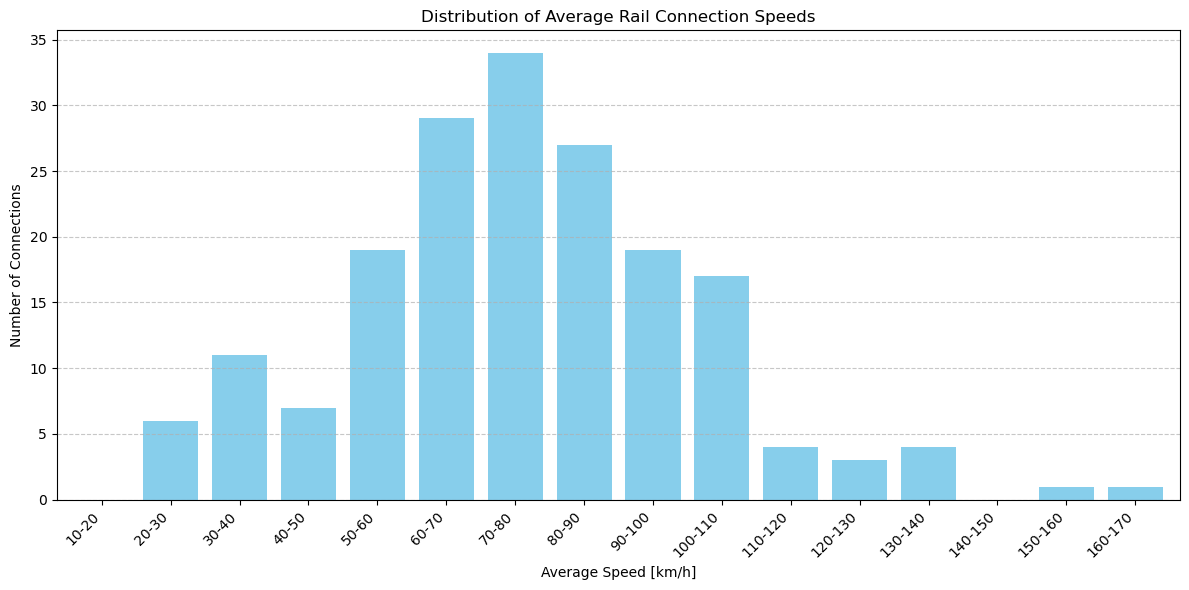

Number of connections: 182
Percentage of connections with average speeds above 150 km/h: 1.10%
Percentage of connections with average speeds below 60 km/h: 23.63%


In [122]:
# find min and max avg speed 
df_airandrail_short_sorted = df_airandrail_short.sort_values(by='straight_line_speed_rail', ascending=False)

# Get the maximum average speed
max_avg_speed = df_airandrail_short_sorted['straight_line_speed_rail'].iloc[0]
print(f"Maximum Average Speed: {max_avg_speed} km/h")

# Get the minimum average speed
min_avg_speed = df_airandrail_short_sorted['straight_line_speed_rail'].iloc[-1]
print(f"Minimum Average Speed: {min_avg_speed} km/h")



# create avg_speed groups

bins = np.arange(10,180,10) # bins for avg speed
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
df_airandrail_short['speed_group'] = pd.cut(df_airandrail_short['straight_line_speed_rail'], bins=bins, labels=labels, right=False)

speed_group_counts = df_airandrail_short['speed_group'].value_counts(sort=False)
#print(speed_group_counts)

plt.figure(figsize=(12, 6))
speed_group_counts.plot(kind='bar', color='skyblue', width=0.8)
plt.title("Distribution of Average Rail Connection Speeds")
plt.ylabel('Number of Connections')
plt.xlabel('Average Speed [km/h]')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# calculate percentages
# Calculate total number of connections
total_connections_rail = len(df_airandrail_short)

# Calculate the number of connections above 150 km/h
connections_above_150 = df_airandrail_short[df_airandrail_short['straight_line_speed_rail'] > 150].shape[0]

# Calculate the number of connections below 60 km/h
connections_below_60 = df_airandrail_short[df_airandrail_short['straight_line_speed_rail'] < 60].shape[0]

# Calculate percentages
percentage_above_150 = (connections_above_150 / total_connections_rail) * 100
percentage_below_60 = (connections_below_60 / total_connections_rail) * 100

# Display results
print(f"Number of connections: {total_connections_rail}")
print(f"Percentage of connections with average speeds above 150 km/h: {percentage_above_150:.2f}%")
print(f"Percentage of connections with average speeds below 60 km/h: {percentage_below_60:.2f}%")





# change this when we have straight line distances for all rail connections

to include all rail connections as in the eu paper instead of only the one where a rail and air connection exists


In [56]:
# calculate for how many connections the rail connection is quicker
#df_airandrail = df_airandrail_short

#get number 
display(df_airandrail.head())
print(len(df_airandrail))

df_rail_quickest = df_airandrail[df_airandrail["total_travel_time_minutes_rail"]< df_airandrail['total_travel_time_minutes_air']]
df_rail_quickest = df_rail_quickest.drop_duplicates(subset= ['normalized_connection_air'])

# Filter out rows where both columns are 0
df_rail_quickest = df_rail_quickest[
    ~((df_rail_quickest["scraped_travel_time_minutes"] == 0) | 
      (df_rail_quickest["total_travel_time_minutes_rail"] == 0))
]

# Display the updated DataFrame
print(f"Number of rows after filtering: {len(df_rail_quickest)}")


print(f'Total number of connections where rail connection is quicker than air: {len(df_rail_quickest)}')
print(f'Total number of connections where rail connection is quicker than air (<500km): {len(df_rail_quickest[df_rail_quickest['distance_km_air']<500])}')
print(f'Percentage of connections where rail is quicker (<500km): {100*len(df_rail_quickest[df_rail_quickest['distance_km_air']<500])/len(df_airandrail_short):.3f}')
#df_rail_quickest = df_rail_quickest.sort_values(by = 'distance_km_air')
#display(df_rail_quickest)



,city1_rail,city2_rail,distance_km_rail,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time,scraped_travel_time_minutes,additional_time_minutes,...,AirportLon1,Airport_Code1,city2_air,AirportLat2,AirportLon2,Airport_Code2,distance_km_air,total_travel_time_minutes_air,Route Exists,normalized_connection_air
0,paris,istanbul,2850.72,24.64,115.70,0.58,1.06,0,0,2.46,...,2.55,CDG,istanbul,40.898600,29.309200,SAW,2275.433018,324.718148,True,istanbul-paris
1,paris,london,453.97,3.74,121.25,0.58,0.12,"2 Std., 18 Min.",138,1.05,...,2.55,CDG,london,51.874444,-0.368333,LTN,379.349963,198.312610,True,london-paris
2,paris,madrid,1412.47,8.27,170.70,0.58,1.24,"10 Std., 46 Min.",646,2.73,...,2.55,CDG,madrid,40.472222,-3.560833,MAD,1064.416862,243.983737,True,madrid-paris
3,paris,barcelona,1074.87,5.30,202.80,0.58,1.09,"7 Std., 7 Min.",427,2.50,...,2.55,CDG,barcelona,41.296944,2.078333,BCN,858.753473,230.272845,True,barcelona-paris
4,paris,berlin,1037.61,6.94,149.53,0.58,1.44,"7 Std., 51 Min.",471,3.03,...,2.55,CDG,berlin,52.559444,13.287500,TXL,850.475121,229.720954,True,berlin-paris


1141
Number of rows after filtering: 30
Total number of connections where rail connection is quicker than air: 30
Total number of connections where rail connection is quicker than air (<500km): 28
Percentage of connections where rail is quicker (<500km): 15.385


Thesis: on average we have longer connections than eupaper 
evidence: much quicker average rail connection speed -> long distance high speed rail

TODO: check if average connection length is given in eu paper

In [57]:


print(f'Average rail connection length (rail quicker than air): {df_rail_quickest['distance_km_rail'].mean():.2f} km')
print(f'Average air connection length (rail quicker than air): {df_rail_quickest['distance_km_air'].mean():.2f} km')

print(f'Average rail connection length: {df_airandrail['distance_km_rail'].mean():.2f} km')
print(f'Average air connection length: {df_airandrail['distance_km_air'].mean():.2f} km')

print(f'Average rail connection length (<500km): {df_airandrail[df_airandrail['distance_km_rail'] < 500]['distance_km_rail'].mean()
:.2f} km')
print(f'Average air connection length(<500km): {df_airandrail[df_airandrail['distance_km_air'] < 500]['distance_km_air'].mean()
:.2f} km')


print(f'Median rail connection length (rail quicker than air): {df_rail_quickest['distance_km_rail'].median():.2f} km')
print(f'Median air connection length (rail quicker than air): {df_rail_quickest['distance_km_air'].median():.2f} km')

print(f'Median rail connection length: {df_airandrail['distance_km_rail'].median():.2f} km')
print(f'Median air connection length: {df_airandrail['distance_km_air'].median():.2f} km')




Average rail connection length (rail quicker than air): 330.21 km
Average air connection length (rail quicker than air): 270.73 km
Average rail connection length: 1582.07 km
Average air connection length: 1157.78 km
Average rail connection length (<500km): 371.34 km
Average air connection length(<500km): 365.23 km
Median rail connection length (rail quicker than air): 308.81 km
Median air connection length (rail quicker than air): 249.26 km
Median rail connection length: 1473.35 km
Median air connection length: 1064.97 km


In [58]:
print(f"Average rail speed (rail beats air): {df_rail_quickest['average_speed'].mean()}")
print(f"Average rail speed (rail beats air < 500km): {df_rail_quickest[df_rail_quickest['distance_km_rail'] < 500]['average_speed'].mean()}")

Average rail speed (rail beats air): 158.17299999999997
Average rail speed (rail beats air < 500km): 150.17038461538462


#### Analysis
connection analysis does not match EU paper findings at all 

- whole rail database (2850 connections our database vs 1356 EU)
    - avg speed above 150 kmh: EU 3% vs Our calculation 6.6%
    - avg speed below 60 kmh: EU 30% vs Our calculation 19%

- less than 500 km connection rail database (245 connections our db vs - EU)
    - avg speed above 150 kmh: EU 3% vs Our calculation 25%
    - avg speed below 60 kmh: EU 30% vs Our calculation 0%


 - rail/air comparison less than 500km apart (113 connections our db vs 297 EU):  
    - 235 connections if all connections are considered bidirectional 
        - might not be applicable for air connecions
    - total number of connections where rail beats air: 30
    - total number of connections where rail beats air (<500 km): 26
        - 1.8 percent of connections vs 23 percent EU
    - average rail connection length: 1599km
    - average rail connection length (<500km): 380 km
    - average rail connection length (rail beats air): 330km out calculation vs EU 177km
    - average rail connection speed (rail beats air <500 km): 150 km/h vs 117km/h EU

    => our average connection is way to long 




In [183]:

df_airandrail_short['delta_time_hours'] = df_airandrail_short['total_travel_time_minutes_air']/60 - df_airandrail_short['total_travel_time_minutes_rail']/60

display(df_airandrail_short.head())


,city1_rail,city2_rail,distance_km_rail,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time,scraped_travel_time_minutes,additional_time_minutes,...,ASCII Name_x,Alternate Names_x,CityLatitude_x,CityLongitude_x,Population_y,ASCII Name_y,Alternate Names_y,CityLatitude_y,CityLongitude_y,delta_time_hours
0,paris,london,453.97,3.74,121.25,0.58,0.12,"2 Std., 18 Min.",138,1.05,...,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,0.454377
1,paris,lyon,433.02,1.77,244.24,0.58,0.50,"1 Std., 53 Min.",113,1.62,...,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,0.898337
2,paris,brussels,314.04,2.15,146.12,0.58,1.08,"1 Std., 22 Min.",82,2.49,...,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,1.222339
3,paris,birmingham,636.85,5.34,119.29,0.58,0.19,"4 Std., 14 Min.",254,1.16,...,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,-1.360575
4,paris,amsterdam,521.79,3.62,144.22,0.58,0.81,"3 Std., 24 Min.",204,2.08,...,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.3488,-0.641764


In [233]:
# drop connections where time delta > 10h

df_airandrail_short.drop(df_airandrail_short[df_airandrail_short['delta_time_hours'] < -10].index, inplace= True)

Maximum Time Delta (air-rail): 1.5254069521611675 hours
Minimum Time Delta (air-rail): -8.11842838231259 hours


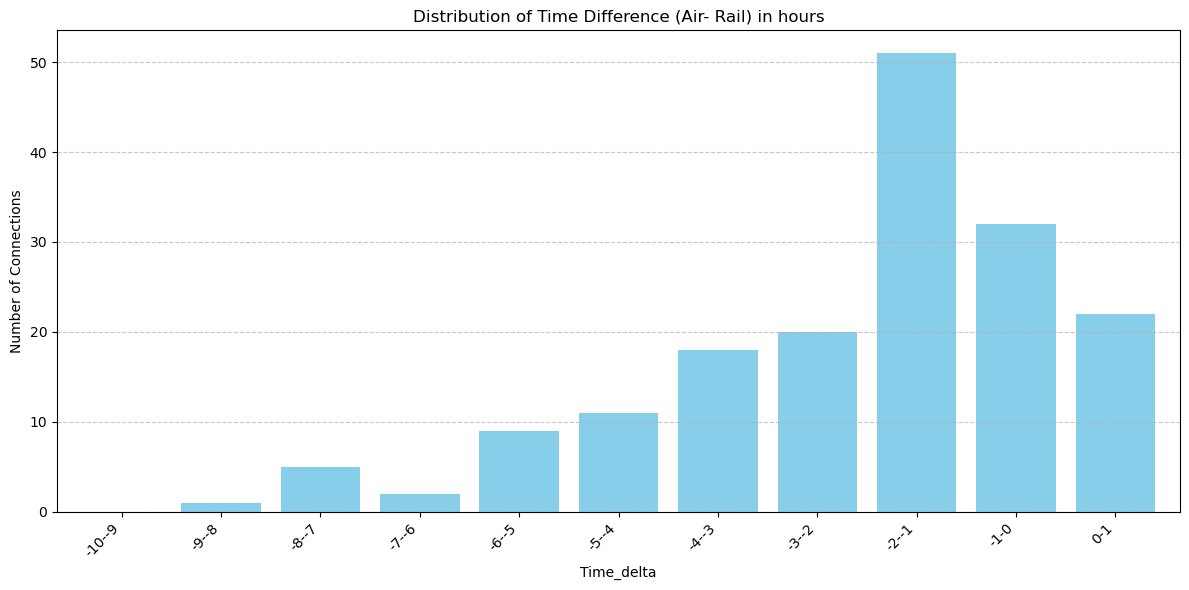

In [235]:
# find min and max avg speed 
df_airandrail_short_sorted = df_airandrail_short.sort_values(by='delta_time_hours', ascending=False)

# Get the maximum average speed
max_delta_time = df_airandrail_short_sorted['delta_time_hours'].iloc[0]
print(f"Maximum Time Delta (air-rail): {max_delta_time} hours")

# Get the minimum average speed
min_delta_time = df_airandrail_short_sorted['delta_time_hours'].iloc[-1]
print(f"Minimum Time Delta (air-rail): {min_delta_time} hours")



# create avg_speed groups

bins = np.arange(-10,2,1) # bins for avg speed
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
df_airandrail_short['delta_time_group'] = pd.cut(df_airandrail_short['delta_time_hours'], bins=bins, labels=labels, right=False)

time_group_counts = df_airandrail_short['delta_time_group'].value_counts(sort=False)
#print(time_group_counts)

plt.figure(figsize=(12, 6))
time_group_counts.plot(kind='bar', color='skyblue', width=0.8)
plt.title("Distribution of Time Difference (Air- Rail) in hours")
plt.ylabel('Number of Connections')
plt.xlabel('Time_delta')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [195]:
display(df_airandrail_short_sorted.head())

,city1_rail,city2_rail,distance_km_rail,estimated_time_in_trains,average_speed,distance_to_first_station_city1,distance_to_first_station_city2,scraped_travel_time,scraped_travel_time_minutes,additional_time_minutes,...,ASCII Name_x,Alternate Names_x,CityLatitude_x,CityLongitude_x,Population_y,ASCII Name_y,Alternate Names_y,CityLatitude_y,CityLongitude_y,delta_time_hours
100,munich,nürnberg,172.84,0.87,198.98,0.52,1.00,"1 Std., 2 Min.",62,2.28,...,munich,"lungsod ng muenchen,lungsod ng münchen,muc,min...",48.13743,11.57549,1512491.0,munich,"lungsod ng muenchen,lungsod ng münchen,muc,min...",48.13743,11.57549,1.525407
2,paris,brussels,314.04,2.15,146.12,0.58,1.08,"1 Std., 22 Min.",82,2.49,...,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.34880,10306512.0,paris,"baariis,bahliz,baris,lungsod ng paris,lutece,l...",48.85341,2.34880,1.222339
143,frankfurt am main,düsseldorf,214.92,1.04,207.41,1.47,1.13,"1 Std., 9 Min.",69,3.90,...,frankfurt am main,"fra,francfort,francfort - frankfurt am main,fr...",50.11552,8.68417,773068.0,frankfurt am main,"fra,francfort,francfort - frankfurt am main,fr...",50.11552,8.68417,1.196223
142,frankfurt am main,stuttgart,178.96,1.13,157.78,1.47,0.30,"1 Std., 11 Min.",71,2.66,...,frankfurt am main,"fra,francfort,francfort - frankfurt am main,fr...",50.11552,8.68417,773068.0,frankfurt am main,"fra,francfort,francfort - frankfurt am main,fr...",50.11552,8.68417,1.148444
53,naples,rome,212.63,1.26,168.16,0.41,0.24,"1 Std., 6 Min.",66,0.97,...,naples,"nap,napels,naples,naplés,napoles,napoli,napolo...",40.85216,14.26811,2809357.0,naples,"nap,napels,naples,naplés,napoles,napoli,napolo...",40.85216,14.26811,1.141344


# Visualization

In [236]:
#initialize directed graphs for rail and air network``
airandrail_graph = nx.Graph()
air_graph = nx.DiGraph()
GraphSize = (10,7)

geo_positions = {}

df_airandrail_short_sorted = df_airandrail_short.sort_values(by='delta_time_hours', ascending=True)



# Add edges for the rail network
for _, row in df_airandrail_short_sorted.iterrows():
    geo_positions[row['city1_rail']] = (row['CityLongitude_x'], row['CityLatitude_x'])
    airandrail_graph.add_edge(row['city1_rail'], row['city2_rail'], weight=row['delta_time_hours'])


print(f"Number of nodes: {airandrail_graph.number_of_nodes()}")
print(f"Number of edges: {airandrail_graph.number_of_edges()}")


# # Add edges for the air network
# for _, row in df_air.iterrows():
#     air_graph.add_edge(row['city1'], row['city2'], weight=row['total_travel_time_minutes'])
# print(f"Number of nodes: {air_graph.number_of_nodes()}")
# print(f"Number of edges: {air_graph.number_of_edges()}")



Number of nodes: 63
Number of edges: 177


In [237]:
# Extract the list of cities from airandrail_graph
cities_in_graph = [node for node, _ in airandrail_graph.nodes.data('genova')]

# Find cities without positions in geo_positions
cities_without_positions = [city for city in cities_in_graph if city not in geo_positions]

# Find extra positions in geo_positions not used in the graph
extra_positions = [city for city in geo_positions if city not in cities_in_graph]

# Print results
if not cities_without_positions:
    print("All cities in the graph have a position in geo_positions.")
else:
    print("Cities without positions:", cities_without_positions)

if extra_positions:
    print("Extra positions in geo_positions not used in the graph:", extra_positions)
else:
    print("No extra positions in geo_positions.")


Cities without positions: ['sevilla', 'edinburgh', 'poznan', 'palermo', 'zagreb', 'wroclaw', 'bradford', 'genova', 'porto', 'bordeaux', 'bilbao', 'hannover', 'duisburg', 'kraków', 'dortmund', 'málaga', 'konya', 'toulouse', 'ankara', 'hague', 'rotterdam', 'antwerpen']
No extra positions in geo_positions.


In [205]:
for city in cities_without_positions:
    geo_positions[city] = (merged_df[merged_df['city1_rail']== city]['CityLongitude'],merged_df[merged_df['city1_rail']== city]['CityLatitude'])

In [238]:
for city in cities_without_positions:
    # Filter for the row where 'city1_rail' matches the city
    filtered_row = merged_df[merged_df['city1_rail'] == city]
    
    # Ensure the city exists in the DataFrame
    if not filtered_row.empty:
        # Extract scalar values for longitude and latitude
        longitude = filtered_row['CityLongitude'].iloc[0]
        latitude = filtered_row['CityLatitude'].iloc[0]
        
        # Assign to geo_positions
        geo_positions[city] = (longitude, latitude)
    else:
        print(f"City {city} not found in merged_df.")


## !!! get positions for these cities
drop them for now

In [209]:
# Remove cities without positions from the graph
airandrail_graph.remove_nodes_from(cities_without_positions)

# Remove cities without positions from geo_positions
geo_positions = {city: pos for city, pos in geo_positions.items() if city in airandrail_graph.nodes}


In [239]:
from pyproj import Transformer

# Define the transformation (EPSG:4326 is WGS84 for lat/lon, EPSG:3857 is Web Mercator)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)  # Ensure x=lon, y=lat

# Input geographical positions (latitude and longitude)


# Transform the positions to 2D Mercator coordinates
geo_positions_2d = {
    city: transformer.transform(pos[0], pos[1])  # pos[0] = longitude, pos[1] = latitude
    for city, pos in geo_positions.items()
}

# Print transformed coordinates
print(geo_positions_2d)

{'lisboa': (-1016717.6448469294, 4681167.8590734005), 'dublin': (-695623.2528231794, 7044844.207098873), 'københavn': (1398788.4011476028, 7494173.103710547), 'rome': (1392754.8847466074, 5144804.803562149), 'munich': (1288577.6524826305, 6129748.81946962), 'naples': (1588318.7397824146, 4990559.692973105), 'budapest': (2119573.198474786, 6023800.24705892), 'milano': (1022971.5738396954, 5694909.838088431), 'amsterdam': (544317.8009369618, 6868039.484446849), 'madrid': (-412167.09383154294, 4926652.805643734), 'barcelona': (240337.66742776972, 5069858.345922575), 'prague': (1605311.6600520078, 6461536.80159664), 'berlin': (1492853.370867919, 6895499.312861981), 'valencia': (-42263.55787457424, 4789784.255183834), 'vienna': (1822531.6088267385, 6141610.495943203), 'hamburg': (1112417.8978869987, 7085524.945579562), 'dresden': (1529342.786755046, 6630300.516089947), 'bremen': (980409.6797297952, 6997034.901084295), 'marseille': (599017.9723229606, 5357280.444520093), 'düsseldorf': (75431

In [240]:
for node, pos in geo_positions_2d.items():
    if not isinstance(pos, (tuple, list)) or len(pos) != 2 or not all(isinstance(coord, (int, float)) for coord in pos):
        print(f"Invalid position for node {node}: {pos}")

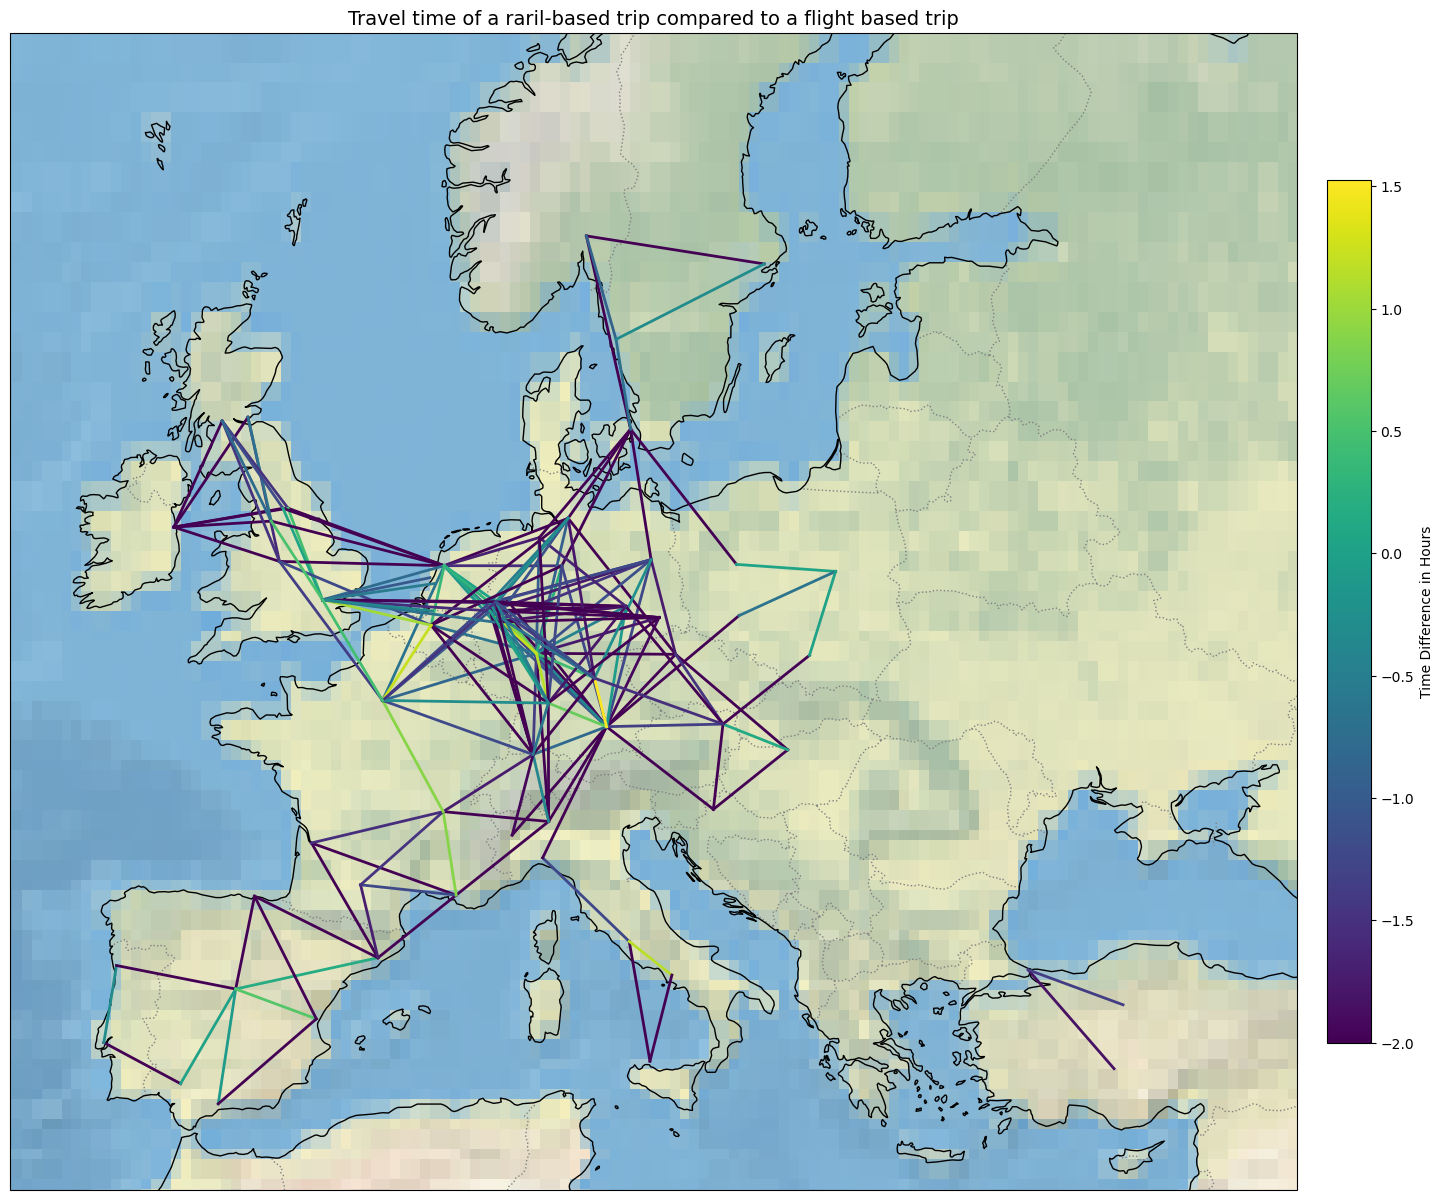

In [247]:
import matplotlib.pyplot as plt
import networkx as nx
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import cm
from matplotlib.colors import Normalize

# Assuming geo_positions_2d is in Mercator (EPSG:3857) projection

# Create a figure with a Cartopy map
fig, ax = plt.subplots(figsize=(20, 16), subplot_kw={'projection': ccrs.Mercator()})

# Add a background map for Europe
ax.stock_img()  # Basic background map
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')  # Country borders
ax.add_feature(cfeature.COASTLINE, edgecolor='black')  # Coastlines
ax.set_extent([-13, 40, 34, 64], crs=ccrs.PlateCarree())  # Extent for Europe (longitude, latitude)

# Normalize the edge weights for color mapping
weights = nx.get_edge_attributes(airandrail_graph, 'weight').values()
#norm = Normalize(vmin=min(weights), vmax=max(weights))
norm = Normalize(vmin=-2, vmax=max(weights))
cmap = cm.viridis  # Use a colormap (e.g., 'viridis')

# Draw the graph using `geo_positions_2d` (which must be in Mercator projection)
# Draw edges with colors based on their weights
for edge in airandrail_graph.edges(data=True):
    start, end, data = edge
    weight = data.get('weight', 1)  # Default weight is 1 if not specified
    color = cmap(norm(weight))  # Map the weight to a color
    x_coords = [geo_positions_2d[start][0], geo_positions_2d[end][0]]
    y_coords = [geo_positions_2d[start][1], geo_positions_2d[end][1]]
    ax.plot(x_coords, y_coords, color=color, linewidth=2, transform=ccrs.Mercator())

# # Draw nodes
# nx.draw_networkx_nodes(
#     airandrail_graph,
#     pos=geo_positions_2d,
#     ax=ax,
#     node_size=700,
#     node_color='lightblue',
#     alpha=1
# )

# # Draw labels
# nx.draw_networkx_labels(
#     airandrail_graph,
#     pos=geo_positions_2d,
#     ax=ax,
#     font_size=10
# )

# Add a colorbar for the weights
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for adding a colorbar
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label('Time Difference in Hours')

# Add a title
plt.title("Travel time of a raril-based trip compared to a flight based trip", fontsize=14)

# Show the plot
plt.show()


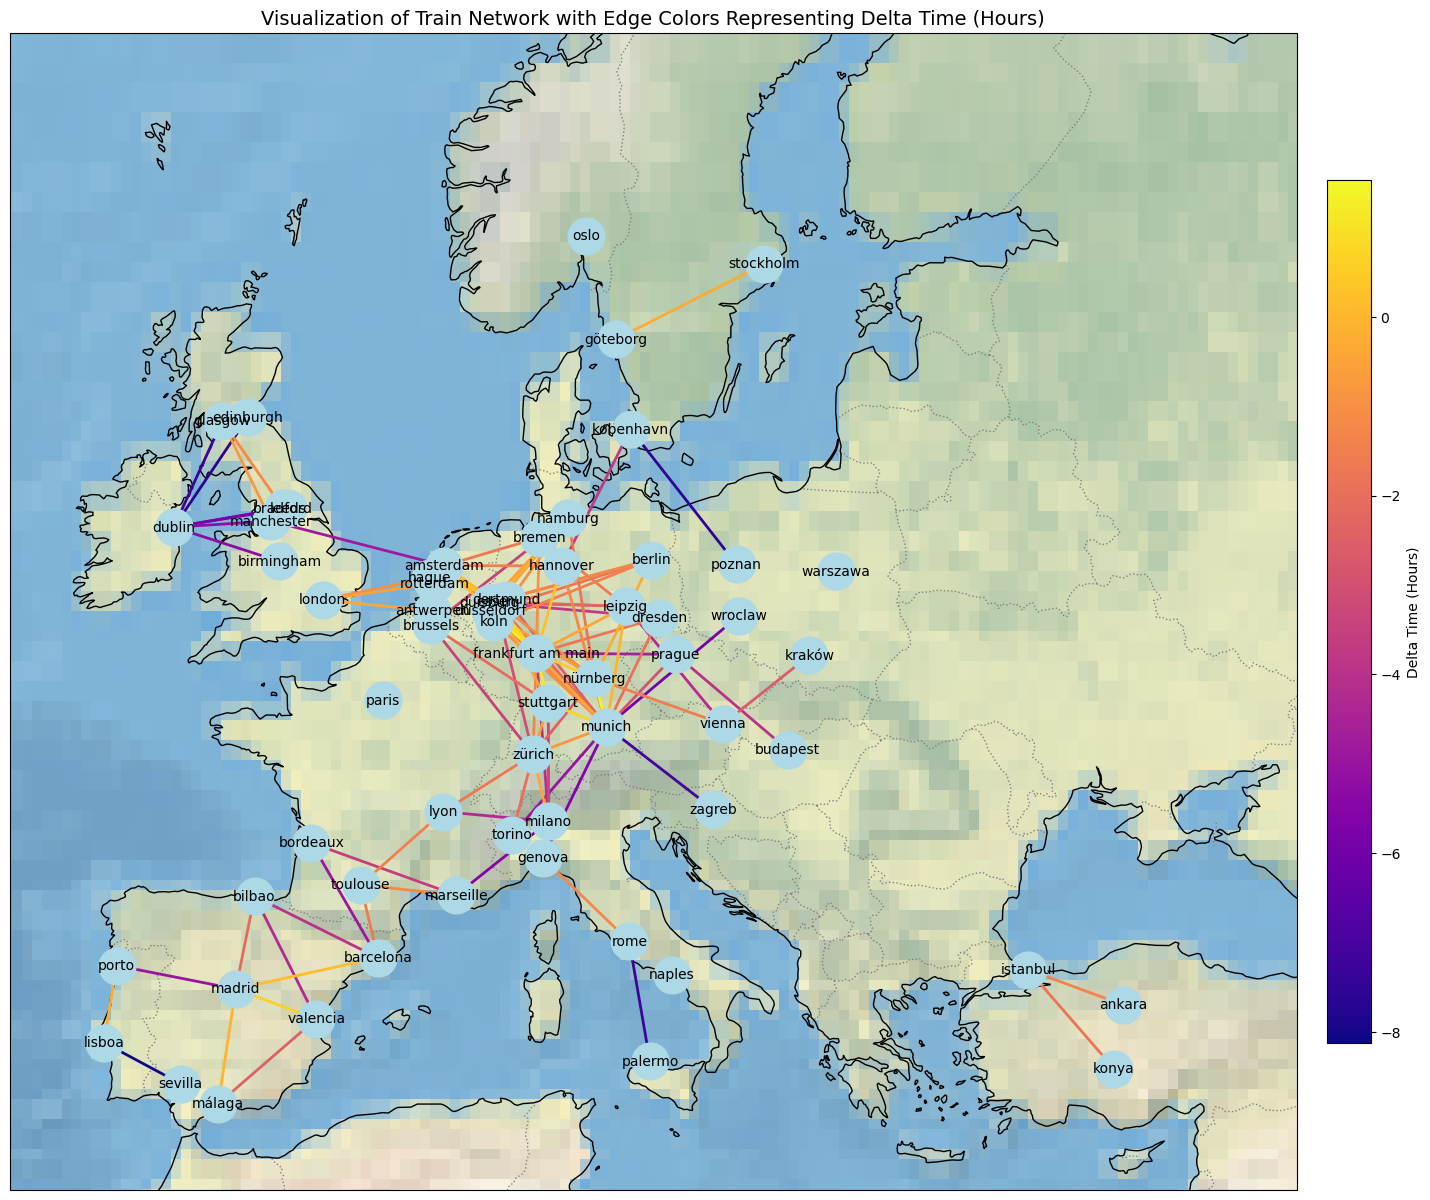

In [246]:
import matplotlib.pyplot as plt
import networkx as nx
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import cm
from matplotlib.colors import Normalize

# Normalize the delta_time_hours for color mapping
delta_times = df_airandrail_short['delta_time_hours']
norm = Normalize(vmin=delta_times.min(), vmax=delta_times.max())
cmap = cm.plasma  # Use a colormap

# Create a figure with a Cartopy map
fig, ax = plt.subplots(figsize=(20, 16), subplot_kw={'projection': ccrs.Mercator()})

# Add a background map for Europe
ax.stock_img()  # Basic background map
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')  # Country borders
ax.add_feature(cfeature.COASTLINE, edgecolor='black')  # Coastlines
ax.set_extent([-13, 40, 34, 64], crs=ccrs.PlateCarree())  # Extent for Europe

# Sort edges by weight (delta_time_hours) in ascending order
sorted_edges = sorted(
    airandrail_graph.edges(data=True), 
    key=lambda edge: (
        df_airandrail_short.loc[
            ((df_airandrail_short['city1_rail'] == edge[0]) & (df_airandrail_short['city2_rail'] == edge[1])) |
            ((df_airandrail_short['city1_rail'] == edge[1]) & (df_airandrail_short['city2_rail'] == edge[0])),
            'delta_time_hours'
        ].iloc[0]
        if not df_airandrail_short[
            ((df_airandrail_short['city1_rail'] == edge[0]) & (df_airandrail_short['city2_rail'] == edge[1])) |
            ((df_airandrail_short['city1_rail'] == edge[1]) & (df_airandrail_short['city2_rail'] == edge[0]))
        ].empty
        else float('inf')  # Assign a default value for unmatched edges
    )
)

# Draw the graph using sorted edges
for edge in sorted_edges:
    start, end, data = edge
    edge_index = df_airandrail_short.index[
        (df_airandrail_short['city1_rail'] == start) & 
        (df_airandrail_short['city2_rail'] == end)
    ].tolist()
    if edge_index:  # Ensure the edge exists in the DataFrame
        delta_time = df_airandrail_short.loc[edge_index[0], 'delta_time_hours']
        color = cmap(norm(delta_time))  # Map the delta_time to a color
        x_coords = [geo_positions_2d[start][0], geo_positions_2d[end][0]]
        y_coords = [geo_positions_2d[start][1], geo_positions_2d[end][1]]
        ax.plot(x_coords, y_coords, color=color, linewidth=2, transform=ccrs.Mercator())

# Draw nodes
nx.draw_networkx_nodes(
    airandrail_graph,
    pos=geo_positions_2d,
    ax=ax,
    node_size=700,
    node_color='lightblue',
    alpha=1
)

# Draw labels
nx.draw_networkx_labels(
    airandrail_graph,
    pos=geo_positions_2d,
    ax=ax,
    font_size=10
)

# Add a colorbar for the delta_time_hours
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for adding a colorbar
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label('Delta Time (Hours)')

# Add a title
plt.title("Visualization of Train Network with Edge Colors Representing Delta Time (Hours)", fontsize=14)

# Show the plot
plt.show()
